# PASSO 3: Notebook de geração de gráficos e índices de referência a partir do arquivo consolidado_geral

**Pipeline MORE · CO₂ incorporado** — 3 de 4

Lê as abas de análise do `consolidado_geral.xlsx` (geradas no Passo 2) e produz
as figuras do relatório. A **última seção** exporta a tabela de índices por
pavimento que alimenta o Passo 4.

| | |
|---|---|
| **Entradas** | `consolidado_geral.xlsx` (do Passo 2), `DIM_FATORES_EMISSAO.xlsx` |
| **Saídas** | figuras PNG/SVG + `indices_referencia_por_pavimento.xlsx` |
| **Próximo passo** | `04_estoque_favela.ipynb` (consome os índices exportados aqui) |

## Índice dos gráficos

Cada seção é independente e pode ser executada isoladamente — **exceto** a
última, que gera um arquivo necessário ao Passo 4.

| Seção | Aba consumida | Saída |
|---|---|---|
| Dumbbell agrupado (CO₂/m² por categoria e moradia) | `QUANTITATIVOS`, `Ambientes_Padronizados` | `..._grafico_CO2_por_m2.png/.svg` |
| CO₂ médio por tipo construtivo | `Consolidado_Pavimento` | `dumbbell_co2_bootstrap_casas.png` |
| Fatores de emissão por insumo | `DIM_FATORES_EMISSAO` | `grafico_A_fatores_emissao.png` |
| Participação de materiais no CO₂ | `QUANTITATIVOS`, `Consolidado_Pavimento`, `DIM_FATORES_EMISSAO` | `grafico_B_participacao_co2.png` |
| Quantitativo de materiais por tipo | `QUANTITATIVOS` | `grafico_empilhado_medias_por_tipo.png/.svg` |
| Intensidade estrutural por tipologia | `Consolidado_Pavimento` | `grafico_intensidade_estrutural.png` |
| CO₂ médio por pavimento | `Consolidado_Pavimento` | `dumbbell_co2_bootstrap_pavimentos.png` |
| Participação dos materiais por pavimento | `QUANTITATIVOS`, `Consolidado_Pavimento`, `DIM_FATORES_EMISSAO` | `grafico_B_por_pavimento.png` |
| Materiais e custo por pavimento | `Consolidado_Pavimento` | `grafico_intensidade_por_pavimento.png` |
| **Índices finais para a favela** | `Consolidado_Pavimento` | **`indices_referencia_por_pavimento.xlsx`** ← Passo 4 |

### Sobre a definição de tipologias (`config_tipos`)

Várias seções agrupam as moradias por tipo construtivo usando um dicionário
`config_tipos` que mapeia `id_moradia → tipologia`. **Esse dicionário está hoje
repetido em cada célula que o utiliza**, pois na fase inicial foram feitas muitas análises exploratórias. 
Ao atualizar a amostra (incluir/remover
casas ou reclassificar tipologias), edite **todas** as ocorrências para
mantê-las sincronizadas. A unificação numa única definição (gráficos unificados para todas as favelas) está prevista no
*Roadmap* (README).

# Análise geral - Dumbbell agupado (CO2 Mín-Máx por m²)

Representação para comparar as faixas de CO2 de todas as casas, agrupadas por categorias. Útil para verificar a presença de outliers e validar o uso de faixas médias de CO2. Consome as abas `QUANTITATIVOS`, `Ambientes_Padronizados` e gera como saída `..._grafico_CO2_por_m2.png/.svg` 

Lendo arquivo: consolidado_geral.xlsx
AVISO: Categorias não mapeadas (ignoradas):
['VERIFICAR']
Grupos de pavimentos: ['1 pavimento', '2 pavimentos', '3 pavimentos', '4 pavimentos']
Plotando 39 moradias em 4 grupo(s)...
✅ Gráfico salvo em:
   /outputs/figures/consolidado_geral_grafico_CO2_por_m2.png


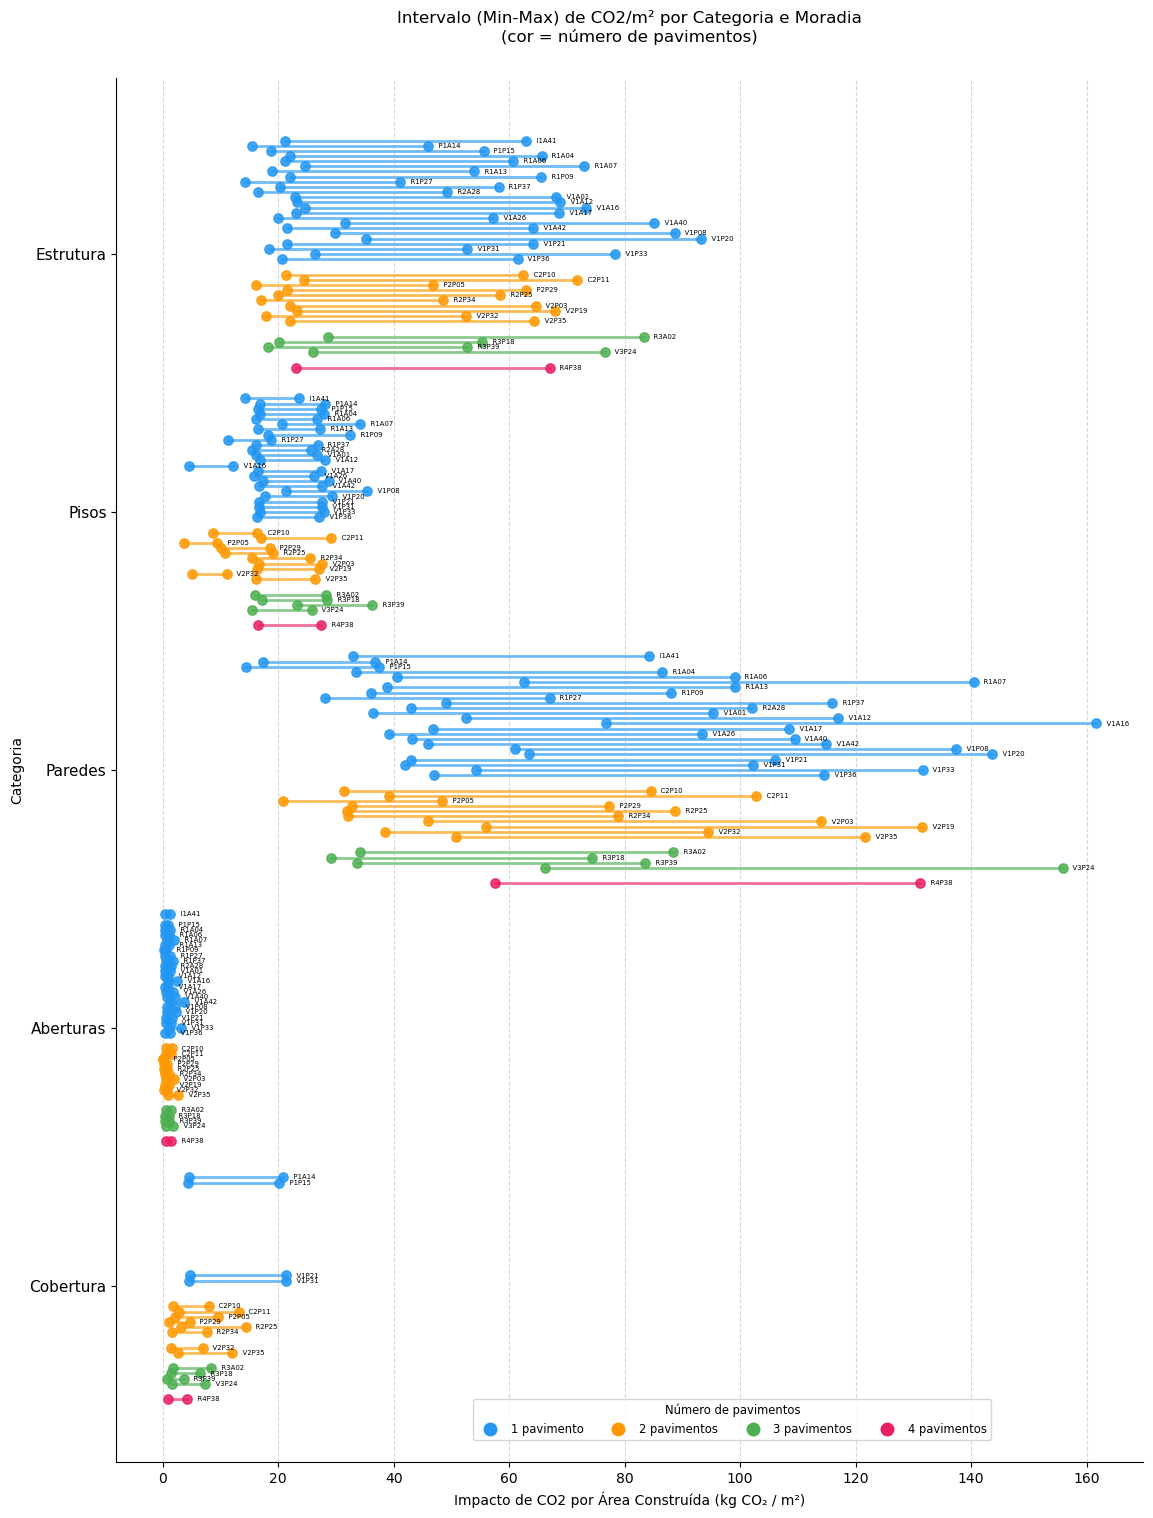

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ================================================================
# Gráfico Grouped Dumbbell Plot (CO2 Mín-Máx por m²)
# ================================================================

# ===== Parâmetros =====
path_consolidado = r"/data/interim/consolidado_geral.xlsx"

categoria_ordem   = ["Estrutura", "Pisos", "Paredes", "Aberturas", "Cobertura"]
gap_entre_grupos  = 2.0   # slots extras de espaço entre grupos de pavimentos
spacing_cat       = 2.0   # distância vertical entre categorias (aumentar para mais espaço)

# ===== Leitura das abas =====
try:
    path = Path(path_consolidado)
    if not path.exists():
        raise FileNotFoundError(f"Arquivo não encontrado em: {path_consolidado}")

    print(f"Lendo arquivo: {path.name}")
    dq  = pd.read_excel(path, sheet_name="QUANTITATIVOS")
    amb = pd.read_excel(path, sheet_name="Ambientes_Padronizados")
    dq.columns  = [c.strip() for c in dq.columns]
    amb.columns = [c.strip() for c in amb.columns]
except FileNotFoundError as e:
    print(e); exit()
except Exception as e:
    print(f"Ocorreu um erro inesperado: {e}"); exit()

if not all(c in dq.columns  for c in ['co2_min', 'co2_max', 'categoria_dicionario', 'id_moradia']):
    print("Erro: colunas essenciais ausentes na aba 'QUANTITATIVOS'."); exit()
if not all(c in amb.columns for c in ['area_bim', 'pavimento_bim', 'id_moradia']):
    print("Erro: colunas essenciais ausentes na aba 'Ambientes_Padronizados'."); exit()


# ===== Mapeamento de categoria: Melhor visualização. Pode ser ajustado conforme necessário =====
def map_categoria(cat):
    if isinstance(cat, str):
        cat_stripped = " ".join(cat.split()).strip()
        if cat_stripped in ["Janelas", "Portas"]:              return "Aberturas"
        if cat_stripped in ["Quadro estrutural", "Escadas"]:   return "Estrutura"
        if cat_stripped in ["Pisos", "Paredes", "Cobertura"]:  return cat_stripped
        if cat_stripped == "Telhados":                         return "Cobertura"
    return "Outros"

dq["Categoria_grp"] = dq["categoria_dicionario"].apply(map_categoria)

cats_ignoradas = dq[dq["Categoria_grp"] == "Outros"]["categoria_dicionario"].unique()
if len(cats_ignoradas) > 0:
    print("AVISO: Categorias não mapeadas (ignoradas):")
    print([c for c in cats_ignoradas if isinstance(c, str) and c.strip()])


# ===== Agrupamento por número de pavimentos =====
n_pav_df = (
    amb.groupby("id_moradia")["pavimento_bim"]
    .nunique().reset_index()
    .rename(columns={"pavimento_bim": "n_pavimentos"})
)
n_pav_df["grupo_pav"] = n_pav_df["n_pavimentos"].apply(
    lambda n: f"{n} pavimento{'s' if n > 1 else ''}"
)
grupos_ordenados = (
    n_pav_df[["n_pavimentos", "grupo_pav"]].drop_duplicates()
    .sort_values("n_pavimentos")["grupo_pav"].tolist()
)
n_grupos = len(grupos_ordenados)
print(f"Grupos de pavimentos: {grupos_ordenados}")

moradia_para_grupo = n_pav_df.set_index("id_moradia")["grupo_pav"].to_dict()
moradia_para_n_pav = n_pav_df.set_index("id_moradia")["n_pavimentos"].to_dict()


# ===== Área, CO2 e merge =====
geral_area = (
    amb.groupby("id_moradia", as_index=False)
    .agg(Area_m2=('area_bim', 'sum'))
    .pipe(lambda df: df[df["Area_m2"] > 0])
)

agg_co2 = (
    dq.groupby(["id_moradia", "Categoria_grp"], as_index=False)
    .agg(co2_min_total=('co2_min', 'sum'), co2_max_total=('co2_max', 'sum'))
)

merged_data = (
    agg_co2
    .merge(geral_area, on="id_moradia", how="left")
    .merge(n_pav_df[["id_moradia", "grupo_pav", "n_pavimentos"]], on="id_moradia", how="left")
)

merged_data["Area_m2"] = merged_data["Area_m2"].replace(0, np.nan)
sem_area = merged_data[merged_data["Area_m2"].isnull()]["id_moradia"].unique()
if len(sem_area):
    print(f"Aviso: Moradias sem área — excluídas: {sem_area}")
    merged_data = merged_data.dropna(subset=["Area_m2"])

merged_data["co2_min_m2"] = merged_data["co2_min_total"] / merged_data["Area_m2"]
merged_data["co2_max_m2"] = merged_data["co2_max_total"] / merged_data["Area_m2"]
merged_data["Categoria_grp"] = pd.Categorical(
    merged_data["Categoria_grp"], categories=categoria_ordem, ordered=True
)
merged_data = merged_data.dropna(subset=["Categoria_grp"]).sort_values("Categoria_grp")

# Remove entradas onde ambos os valores de CO2 são 0
merged_data = merged_data[
    (merged_data["co2_min_m2"] != 0) | (merged_data["co2_max_m2"] != 0)
]

# ===== Cores por grupo =====
palette    = ["#2196F3", "#FF9800", "#4CAF50", "#E91E63", "#9C27B0", "#00BCD4"]
cores_grupo = {g: palette[i % len(palette)] for i, g in enumerate(grupos_ordenados)}


# ===== Ordem das moradias: por n_pavimentos, depois por nome =====
todas_moradias = merged_data["id_moradia"].unique()
moradias_ordem = sorted(todas_moradias, key=lambda m: (moradia_para_n_pav.get(m, 0), m))
n_moradias = len(moradias_ordem)

if n_moradias == 0:
    print("Nenhuma moradia com dados válidos."); exit()

print(f"Plotando {n_moradias} moradias em {n_grupos} grupo(s)...")


# ===== Offsets: 1 slot por moradia + gap entre grupos =====
slot_positions = []
slot = 0
for grupo in grupos_ordenados:
    for m in moradias_ordem:
        if moradia_para_grupo.get(m) == grupo:
            slot_positions.append(slot)
            slot += 1
    slot += gap_entre_grupos

group_height = spacing_cat * 0.88   # ocupa 88% do espaço entre categorias
s_min, s_max = slot_positions[0], slot_positions[-1]
s_center = (s_min + s_max) / 2
offsets_norm = [
    (s - s_center) / (s_max - s_min) * group_height if s_max != s_min else 0
    for s in slot_positions
]
moradia_offset = {m: offsets_norm[j] for j, m in enumerate(moradias_ordem)}

# Posições y das categorias com spacing ampliado
y_pos_categorias = np.arange(len(categoria_ordem)) * spacing_cat


# ===== Plot =====
fig_height = max(8, n_moradias * 0.35 + 3)
fig, ax = plt.subplots(figsize=(14, fig_height))

for i, cat in enumerate(categoria_ordem):
    for moradia in moradias_ordem:
        data = merged_data[
            (merged_data["Categoria_grp"] == cat) &
            (merged_data["id_moradia"] == moradia)
        ]
        if not data.empty:
            min_val = data["co2_min_m2"].values[0]
            max_val = data["co2_max_m2"].values[0]
            grupo   = moradia_para_grupo.get(moradia, grupos_ordenados[0])
            cor     = cores_grupo[grupo]
            y       = y_pos_categorias[i] + moradia_offset[moradia]

            ax.plot([min_val, max_val], [y, y], color=cor, linewidth=2.0, alpha=0.65, zorder=1)
            ax.scatter([min_val, max_val], [y, y], color=cor, s=45, zorder=2, alpha=0.85)

            # Rótulo da moradia à direita do ponto máximo
            ax.text(
                max_val+1, y, f"  {moradia}",
                ha="left", va="center",
                fontsize=5, alpha=1,
                clip_on=False
            )


# ===== Estética =====
ax.set_yticks(y_pos_categorias)
ax.set_yticklabels(categoria_ordem, fontsize=11)
ax.set_ylabel("Categoria")
ax.invert_yaxis()

ax.set_xlabel("Impacto de CO2 por Área Construída (kg CO₂ / m²)")
ax.set_title(
    "Intervalo (Min-Max) de CO2/m² por Categoria e Moradia\n(cor = número de pavimentos)",
    y=1.02
)

ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


# ===== Legenda: apenas o grupo (sem lista de casas) =====
legend_handles = [
    plt.Line2D(
        [0], [0], marker='o', color='w',
        label=grupo,
        markerfacecolor=cores_grupo[grupo],
        markersize=9, markeredgecolor=cores_grupo[grupo]
    )
    for grupo in grupos_ordenados
]

ax.legend(
    handles=legend_handles,
    title="Número de pavimentos",
    loc="upper center",
    bbox_to_anchor=(0.6, 0.05),
    ncol=n_grupos,
    fontsize='small',
    title_fontsize='small',
    frameon=True,
)

fig.tight_layout()
fig.subplots_adjust(bottom=0.12, right=0.82)   # espaço para rótulos à direita e legenda abaixo


# ===== Salvar =====
out_path_png = path.parent / f"{path.stem}_grafico_CO2_por_m2.png"
out_path_svg = path.parent / f"{path.stem}_grafico_CO2_por_m2.svg"

try:
    fig.savefig(out_path_png, dpi=160, bbox_inches="tight")
    fig.savefig(out_path_svg, dpi=160, bbox_inches="tight")
    print(f"✅ Gráfico salvo em:\n   {out_path_png}")
    plt.show()
except Exception as e:
    print(f"Erro ao salvar o gráfico: {e}")

# Análise por tipo construtivo

Unidade amostral: a **edificação**. Os pavimentos de cada `id_moradia` são
somados antes de qualquer estatística, respeitando que a unidade é a casa.

> **Amostra deste bloco: n=19 moradias** — apenas as medidas **integralmente**.
> Somar os pavimentos só faz sentido quando a edificação inteira foi levantada;
> por isso as casas com medição parcial ficam de fora aqui (mas entram no bloco
> por nível, com n=39).

## Média de CO2 das casas medidas inteiramente (por tipo construtivo)

- *Agregação por edificação* — os pavimentos de cada id_moradia são somados antes de qualquer estatística, respeitando que a unidade amostral é a casa, não o pavimento.

- *Três pontos por tipo* — mínimo e máximo capturam o envelope de incerteza dos fatores de emissão; o ponto central (min+max)/2 representa a estimativa central de cada casa, mas foi omitido do plot para melhor visualização.

- *Bootstrap percentil 95%* — aplicado separadamente sobre os mínimos, máximos e pontos centrais das casas de cada tipo; reflete a variabilidade amostral entre edificações.

- *Amostra única sem IC* — quando n=1, o bootstrap retorna NaN e nenhuma barra é desenhada; marcado com * no gráfico para transparência.

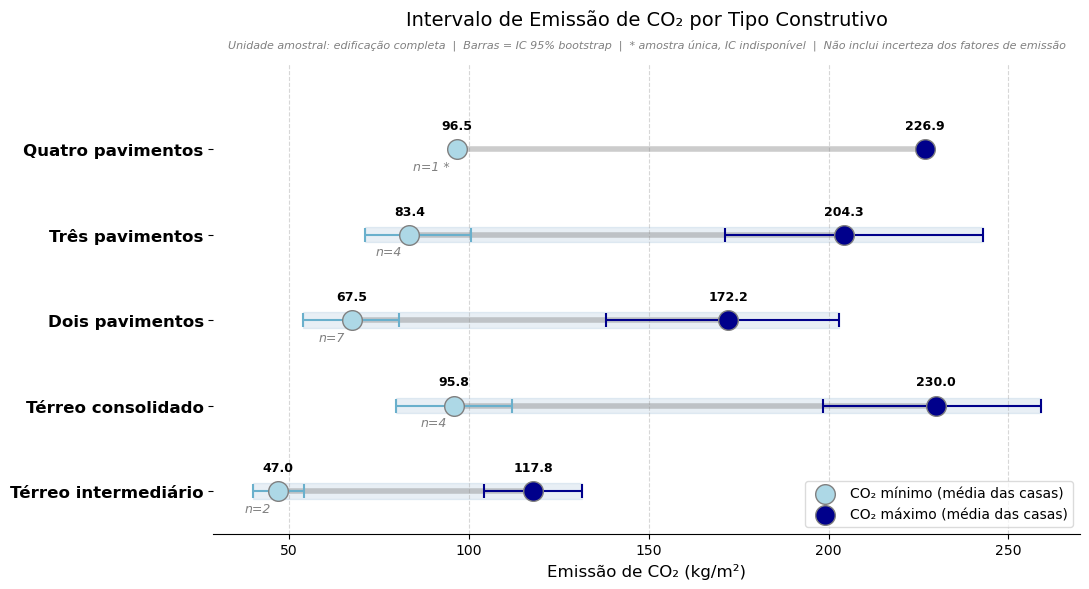

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ==============================================================================
# 1. CARREGAR DADOS
# ==============================================================================
df = pd.read_excel("/data/interim/consolidado_geral.xlsx",
                   sheet_name="Consolidado_Pavimento")

# ==============================================================================
# 2. MAPEAMENTO
# ==============================================================================
config_tipos = {
    'Térreo intermediário': ['P1A14', 'P1P15'],
    'Térreo consolidado':   ['R1A04', 'V1A16', 'V1P20', 'V1P21'],
    'Dois pavimentos':      ['P2P05', 'C2P10', 'C2P11', 'P2P29', 'V2P32', 'V2P03', 'V2P35'],
    'Três pavimentos':      ['R3A02', 'R3P18', 'V3P24', 'R3P39'],
    'Quatro pavimentos':    ['R4P38']
}

map_id_para_tipo = {id_m: tipo for tipo, ids in config_tipos.items() for id_m in ids}
df['Tipo'] = df['id_moradia'].map(map_id_para_tipo)
df = df.dropna(subset=['Tipo'])

# ==============================================================================
# 3. AGREGAÇÃO POR CASA (unidade amostral real = edificação)
#    Soma o CO₂ absoluto dos pavimentos e normaliza pela área total da casa
# ==============================================================================
df_casa = (df.groupby(['id_moradia', 'Tipo'])
             .agg(
                 co2_min_kg    = ('co2_min',               'sum'),
                 co2_max_kg    = ('co2_max',               'sum'),
                 area_total_m2 = ('area_total_pavimento',  'sum')
             )
             .reset_index())

df_casa['CO2 mínimo (kg/m2)'] = df_casa['co2_min_kg'] / df_casa['area_total_m2']
df_casa['CO2 máximo (kg/m2)'] = df_casa['co2_max_kg'] / df_casa['area_total_m2']
df_casa['CO2 medio (kg/m2)']  = (df_casa['CO2 mínimo (kg/m2)'] + df_casa['CO2 máximo (kg/m2)']) / 2

# ==============================================================================
# 4. BOOTSTRAP POR TIPO (sobre casas, não pavimentos)
# ==============================================================================
def bootstrap_ci(data, n_boot=2000, ci=95, seed=42):
    """
    Retorna (média, limite_inferior, limite_superior) via bootstrap percentil.
    Com n < 2, retorna NaN nos limites (sem IC para amostra única).
    """
    data = data.dropna().values
    n = len(data)
    if n < 2:
        return np.mean(data), np.nan, np.nan
    rng = np.random.default_rng(seed)
    boots = [np.mean(rng.choice(data, size=n, replace=True)) for _ in range(n_boot)]
    lower = np.percentile(boots, (100 - ci) / 2)
    upper = np.percentile(boots, 100 - (100 - ci) / 2)
    return np.mean(data), lower, upper

ordem_desejada = ['Térreo intermediário', 'Térreo consolidado', 'Dois pavimentos',
                  'Três pavimentos', 'Quatro pavimentos']

rows = []
for tipo in ordem_desejada:
    sub = df_casa[df_casa['Tipo'] == tipo]
    n_casas = len(sub)

    min_mean, min_lo, min_hi   = bootstrap_ci(sub['CO2 mínimo (kg/m2)'])
    max_mean, max_lo, max_hi   = bootstrap_ci(sub['CO2 máximo (kg/m2)'])
    mid_mean, mid_lo, mid_hi   = bootstrap_ci(sub['CO2 medio (kg/m2)'])

    rows.append({
        'Tipo': tipo, 'n': n_casas,
        'min_mean': min_mean, 'min_lo': min_lo, 'min_hi': min_hi,
        'max_mean': max_mean, 'max_lo': max_lo, 'max_hi': max_hi,
        'mid_mean': mid_mean, 'mid_lo': mid_lo, 'mid_hi': mid_hi,
    })

df_stats = pd.DataFrame(rows)

# ==============================================================================
# 5. PLOTAGEM
# ==============================================================================
fig, ax = plt.subplots(figsize=(11, 6))

cor_min   = '#add8e6'
cor_max   = '#00008b'
cor_mid   = '#4a90a4'
cor_linha = 'grey'

y_pos    = list(range(len(df_stats)))
nomes    = df_stats['Tipo']
vals_min = df_stats['min_mean']
vals_max = df_stats['max_mean']
vals_mid = df_stats['mid_mean']

# --- Erros assimétricos [distância abaixo, distância acima] ---
def erros(df, col):
    lo = (df[f'{col}_mean'] - df[f'{col}_lo']).fillna(0)
    hi = (df[f'{col}_hi']   - df[f'{col}_mean']).fillna(0)
    return [lo, hi]

err_min = erros(df_stats, 'min')
err_max = erros(df_stats, 'max')
err_mid = erros(df_stats, 'mid')

# 1. Linha conectora (entre médias dos extremos)
ax.hlines(y=y_pos, xmin=vals_min, xmax=vals_max,
          color=cor_linha, alpha=0.4, linewidth=4)

# 2. Faixa sombreada: envelope de incerteza combinado (IC boot do min ao IC boot do max)
for i in y_pos:
    lo = df_stats['min_lo'].iloc[i]
    hi = df_stats['max_hi'].iloc[i]
    if not (np.isnan(lo) or np.isnan(hi)):
        ax.fill_betweenx([i - 0.09, i + 0.09], lo, hi,
                         color='steelblue', alpha=0.12, zorder=1)

# 3. Barras de erro nos três pontos
ax.errorbar(vals_min, y_pos, xerr=err_min,
            fmt='none', color='#6ab0cc',
            capsize=5, capthick=1.5, elinewidth=1.5, zorder=2)

ax.errorbar(vals_max, y_pos, xerr=err_max,
            fmt='none', color='#00008b',
            capsize=5, capthick=1.5, elinewidth=1.5, zorder=2)

#ax.errorbar(vals_mid, y_pos, xerr=err_mid,
#            fmt='none', color=cor_mid,
#            capsize=4, capthick=1.2, elinewidth=1.2, zorder=2)

# 4. Pontos
ax.scatter(vals_min, y_pos, color=cor_min, s=200, zorder=3,
           edgecolors='gray', label='CO₂ mínimo (média das casas)')
ax.scatter(vals_max, y_pos, color=cor_max, s=200, zorder=3,
           edgecolors='gray', label='CO₂ máximo (média das casas)')
#ax.scatter(vals_mid, y_pos, color=cor_mid, s=80,  zorder=4,
#           edgecolors='white', linewidths=0.8,
#           marker='D', label='Ponto central [(min+max)/2]')

# 5. Rótulos de valor nos extremos
offset_y = 0.20
for i in y_pos:
    ax.text(vals_min.iloc[i], i + offset_y, f'{vals_min.iloc[i]:.1f}',
            ha='center', va='bottom', color='black', fontsize=9, fontweight='bold')
    ax.text(vals_max.iloc[i], i + offset_y, f'{vals_max.iloc[i]:.1f}',
            ha='center', va='bottom', color='black', fontsize=9, fontweight='bold')

# 6. n amostral à esquerda (indica casas com IC ausente)
x_left = ax.get_xlim()[0] if ax.get_xlim()[0] != 0 else vals_min.min() - 20
for i in y_pos:
    n = df_stats['n'].iloc[i]
    sem_ic = df_stats['min_lo'].isna().iloc[i]
    label = f'n={n}' + (' *' if sem_ic else '')
    ax.text(vals_min.iloc[i] - 2, i-0.20, label,
            ha='right', va='center', color='gray', fontsize=9, style='italic')

# ==============================================================================
# 6. FORMATAÇÃO
# ==============================================================================
ax.set_yticks(y_pos)
ax.set_yticklabels(nomes, fontsize=12, fontweight='bold')
ax.set_xlabel('Emissão de CO₂ (kg/m²)', fontsize=12)
ax.set_title('Intervalo de Emissão de CO₂ por Tipo Construtivo', fontsize=14, pad=28)

# Subtítulo com nota metodológica
ax.text(0.5, 1.03,
        'Unidade amostral: edificação completa  |  Barras = IC 95% bootstrap  |  '
        '* amostra única, IC indisponível  |  Não inclui incerteza dos fatores de emissão',
        transform=ax.transAxes, ha='center', va='bottom',
        fontsize=8, color='gray', style='italic')

ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_ylim(-0.5, len(df_stats) - 1 + 1.0)
ax.legend(loc='lower right', fontsize=10, framealpha=0.7)

plt.tight_layout()
plt.savefig("dumbbell_co2_bootstrap_casas.png", bbox_inches='tight', dpi=150)
plt.show()

## Fatores de emissão por insumo

Mostra, para cada insumo, a amplitude relativa entre os fatores de emissão
mínimo e máximo (% acima do mínimo) e a razão máx/mín. Ordenado por incerteza
crescente. Lido diretamente de `DIM_FATORES_EMISSAO.xlsx` — independe das abas
calculadas. A cor do rótulo indica a unidade do fator (volumétrico, superficial,
mássico, unitário).

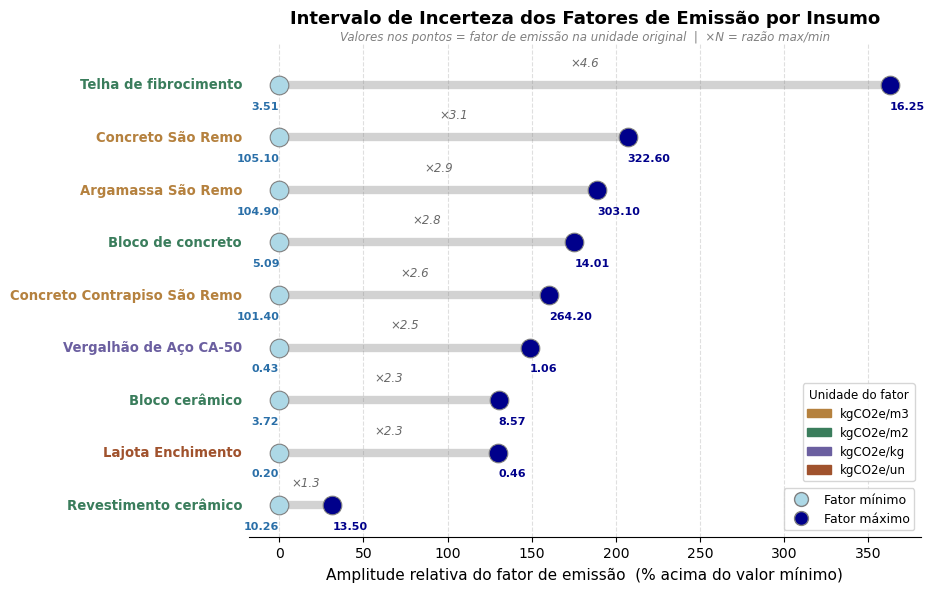

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.transforms import blended_transform_factory

# ==============================================================================
# 1. CARREGAR DADOS
# ==============================================================================
df_fe = pd.read_excel("/data/external/DIM_FATORES_EMISSAO.xlsx")  # ajuste o caminho se necessário
df_fe = df_fe.dropna(subset=['fator_emissao_min', 'fator_emissao_max']).copy()
df_fe['fator_emissao_min'] = df_fe['fator_emissao_min'].astype(float)
df_fe['fator_emissao_max'] = df_fe['fator_emissao_max'].astype(float)

# ==============================================================================
# 2. CALCULAR MÉTRICAS DE AMPLITUDE
# ==============================================================================
df_fe['razao']         = df_fe['fator_emissao_max'] / df_fe['fator_emissao_min']
df_fe['amplitude_rel'] = (df_fe['fator_emissao_max'] - df_fe['fator_emissao_min']) / df_fe['fator_emissao_min'] * 100

# Ordenar por amplitude relativa crescente (menor incerteza → maior)
df_fe = df_fe.sort_values('amplitude_rel', ascending=True).reset_index(drop=True)

# ==============================================================================
# 3. CONFIGURAÇÕES VISUAIS — personalize aqui
# ==============================================================================
cor_min       = '#add8e6'   # azul claro — fator mínimo
cor_max       = '#00008b'   # azul escuro — fator máximo
cor_rotulo_min = '#2a6fa8'  # cor do texto do valor mínimo
tamanho_ponto = 180
espessura_linha = 6

# Cor por unidade de medida (para diferenciar os grupos de insumos no eixo Y)
cores_unidade = {
    'kgCO2e/m3': '#b5813e',   # laranja — volumétrico
    'kgCO2e/m2': '#3a7d5c',   # verde   — superficial
    'kgCO2e/kg': '#6b5fa0',   # roxo    — mássico
    'kgCO2e/un': '#a0522d',   # terra   — unitário
}
df_fe['cor_unidade'] = df_fe['unidade'].map(cores_unidade)
df_fe['label_y']     = df_fe['insumo'] 

# ==============================================================================
# 4. PLOTAGEM
# ==============================================================================
fig, ax = plt.subplots(figsize=(12, 6.5))
fig.subplots_adjust(left=0.32, right=0.88, top=0.88, bottom=0.12)

y_pos = list(range(len(df_fe)))

for i, row in df_fe.iterrows():
    amp = row['amplitude_rel']

    # Linha conectora
    ax.hlines(y=i, xmin=0, xmax=amp, color='grey', alpha=0.35, linewidth=espessura_linha)

    # Pontos mínimo e máximo
    ax.scatter(0,   i, color=cor_min, s=tamanho_ponto, zorder=3, edgecolors='gray', linewidths=0.8)
    ax.scatter(amp, i, color=cor_max, s=tamanho_ponto, zorder=3, edgecolors='gray', linewidths=0.8)

    # Valores originais nos pontos
    ax.text(0, i-0.4, f'{row["fator_emissao_min"]:.2f}',
            ha='right', va='center', fontsize=8, color=cor_rotulo_min, fontweight='bold')
    ax.text(amp , i-0.4, f'{row["fator_emissao_max"]:.2f}',
            ha='left', va='center', fontsize=8, color=cor_max, fontweight='bold')

    # Razão max/min acima da linha
    ax.text(amp / 2, i + 0.30, f'×{row["razao"]:.1f}',
            ha='center', va='bottom', fontsize=8.5, color='dimgray', style='italic')

# Rótulos do eixo Y coloridos por unidade


transform_y = blended_transform_factory(ax.transAxes, ax.transData)

for i, row in df_fe.iterrows():
    ax.text(-0.01, i, row['label_y'],
            ha='right', va='center', fontsize=9.5,
            color=row['cor_unidade'], fontweight='bold',
            transform=transform_y)

# ==============================================================================
# 5. FORMATAÇÃO
# ==============================================================================
ax.set_yticks(y_pos)
ax.set_yticklabels([])
ax.tick_params(axis='y', length=0)

ax.set_xlabel('Amplitude relativa do fator de emissão  (% acima do valor mínimo)', fontsize=11)
ax.set_title('Intervalo de Incerteza dos Fatores de Emissão por Insumo',
             fontsize=13, fontweight='bold', pad=14)
ax.text(0.5, 1.005,
        'Valores nos pontos = fator de emissão na unidade original  |  ×N = razão max/min',
        transform=ax.transAxes, ha='center', fontsize=8.5, color='gray', style='italic')

ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
#ax.set_xlim(-55, 230)
ax.set_ylim(-0.6, len(df_fe) - 0.2)

# Legendas
leg_pontos = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor=cor_min,
           markeredgecolor='gray', markersize=10, label='Fator mínimo'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=cor_max,
           markeredgecolor='gray', markersize=10, label='Fator máximo'),
]
leg_unid = [mpatches.Patch(color=c, label=u) for u, c in cores_unidade.items()]

leg1 = ax.legend(handles=leg_pontos, loc='lower right', fontsize=9, framealpha=0.8)
ax.add_artist(leg1)
ax.legend(handles=leg_unid, loc='lower right', bbox_to_anchor=(1.0, 0.1), fontsize=8.5,
          title='Unidade do fator', title_fontsize=8.5, framealpha=0.8)

plt.savefig("grafico_A_fatores_emissao.png", bbox_inches='tight', dpi=150)
plt.show()

# Participação de materiais no CO₂ total e variabilidade entre edificações

Painel esquerdo: participação % média de cada insumo no CO₂ total da casa
(barras pareadas mín/máx, com desvio padrão entre casas). Painel direito:
coeficiente de variação do CO₂ máx/m² entre casas. Insumos ordenados na mesma
sequência do gráfico de fatores de emissão (incerteza decrescente). Unidade
amostral: a edificação.

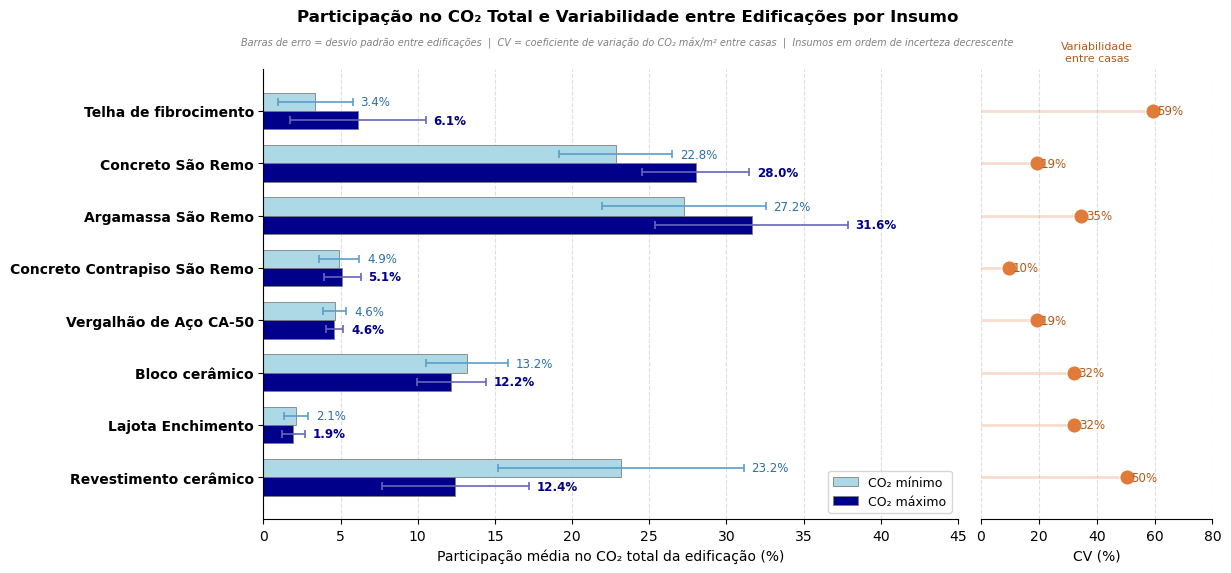

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ==============================================================================
# 1. CARREGAR DADOS
# ==============================================================================
df_quant = pd.read_excel("/data/interim/consolidado_geral.xlsx", sheet_name="QUANTITATIVOS")
df_pav   = pd.read_excel("/data/interim/consolidado_geral.xlsx", sheet_name="Consolidado_Pavimento")
df_fe = pd.read_excel("/data/external/DIM_FATORES_EMISSAO.xlsx")

# ==============================================================================
# 2. MAPEAMENTO DE TIPOLOGIA
# ==============================================================================
config_tipos = {
    'Térreo intermediário': ['P1A14', 'P1P15'],
    'Térreo consolidado':   ['R1A04', 'V1A16', 'V1P20', 'V1P21'],
    'Dois pavimentos':      ['P2P05', 'C2P10', 'C2P11', 'P2P29', 'V2P32', 'V2P03', 'V2P35'],
    'Três pavimentos':      ['R3A02', 'R3P18', 'V3P24', 'R3P39'],
    'Quatro pavimentos':    ['R4P38']
}
map_id = {id_m: tipo for tipo, ids in config_tipos.items() for id_m in ids}
df_quant['Tipo'] = df_quant['id_moradia'].map(map_id)
df_quant = df_quant.dropna(subset=['Tipo'])

# ==============================================================================
# 3. CONTRIBUIÇÃO DE CO2 POR INSUMO POR CASA (normalizada por área)
# ==============================================================================
df_contrib = (df_quant.dropna(subset=['co2_min', 'co2_max'])
              .groupby(['id_moradia', 'insumo'])[['co2_min', 'co2_max']]
              .sum().reset_index())

df_area = df_pav.groupby('id_moradia')['area_total_pavimento'].sum().reset_index()
df_area.columns = ['id_moradia', 'area_total']
df_contrib = df_contrib.merge(df_area, on='id_moradia')
df_contrib['co2_min_m2'] = df_contrib['co2_min'] / df_contrib['area_total']
df_contrib['co2_max_m2'] = df_contrib['co2_max'] / df_contrib['area_total']

# Participação percentual no total de cada casa
df_total = df_contrib.groupby('id_moradia')[['co2_min_m2', 'co2_max_m2']].sum().reset_index()
df_total.columns = ['id_moradia', 'total_min', 'total_max']
df_contrib = df_contrib.merge(df_total, on='id_moradia')
df_contrib['pct_min'] = df_contrib['co2_min_m2'] / df_contrib['total_min'] * 100
df_contrib['pct_max'] = df_contrib['co2_max_m2'] / df_contrib['total_max'] * 100

# ==============================================================================
# 4. AGREGAR POR INSUMO: média, desvio padrão e CV
# ==============================================================================
df_b = (df_contrib.groupby('insumo')
        .agg(
            pct_min_mean=('pct_min', 'mean'),
            pct_min_std =('pct_min', 'std'),
            pct_max_mean=('pct_max', 'mean'),
            pct_max_std =('pct_max', 'std'),
            cv_max      =('co2_max_m2', lambda x: x.std() / x.mean() * 100),
        )
        .reset_index())

# ==============================================================================
# 5. ORDENAR NA MESMA SEQUÊNCIA DO GRÁFICO A (amplitude relativa crescente)
# ==============================================================================

df_fe = df_fe.dropna(subset=['fator_emissao_min', 'fator_emissao_max']).copy()
df_fe['fator_emissao_min'] = df_fe['fator_emissao_min'].astype(float)
df_fe['fator_emissao_max'] = df_fe['fator_emissao_max'].astype(float)
df_fe['amplitude_rel'] = (df_fe['fator_emissao_max'] - df_fe['fator_emissao_min']) / df_fe['fator_emissao_min'] * 100
df_fe = df_fe.sort_values('amplitude_rel', ascending=True).reset_index(drop=True)
ordem_insumos = df_fe['insumo'].tolist()

df_b['insumo'] = pd.Categorical(df_b['insumo'], categories=ordem_insumos, ordered=True)
df_b = df_b.sort_values('insumo').dropna(subset=['insumo']).reset_index(drop=True)

# ==============================================================================
# 6. CONFIGURAÇÕES VISUAIS — personalize aqui
# ==============================================================================
cor_min  = '#add8e6'   # azul claro — CO₂ mínimo
cor_max  = '#00008b'   # azul escuro — CO₂ máximo
cor_cv   = '#e07b3a'   # laranja — CV
altura   = 0.35        # espessura de cada barra

# ==============================================================================
# 7. FIGURA: dois subplots lado a lado
# ==============================================================================
fig, (ax_bar, ax_cv) = plt.subplots(1, 2, figsize=(13, 6),
                                     gridspec_kw={'width_ratios': [3, 1], 'wspace': 0.05})
fig.subplots_adjust(left=0.22, right=0.95, top=0.87, bottom=0.12)

y_pos = np.arange(len(df_b))

# --- PAINEL ESQUERDO: barras horizontais pareadas ---
ax_bar.barh(y_pos + altura/2, df_b['pct_min_mean'],
            height=altura, color=cor_min, edgecolor='gray',
            linewidth=0.6, label='CO₂ mínimo', zorder=2)
ax_bar.barh(y_pos - altura/2, df_b['pct_max_mean'],
            height=altura, color=cor_max, edgecolor='gray',
            linewidth=0.6, label='CO₂ máximo', zorder=2)

# Barras de erro
ax_bar.errorbar(df_b['pct_min_mean'], y_pos + altura/2,
                xerr=df_b['pct_min_std'],
                fmt='none', color='#5a9ec9',
                capsize=3, capthick=1.2, elinewidth=1.2, zorder=3)
ax_bar.errorbar(df_b['pct_max_mean'], y_pos - altura/2,
                xerr=df_b['pct_max_std'],
                fmt='none', color='#6666bb',
                capsize=3, capthick=1.2, elinewidth=1.2, zorder=3)

# Rótulos de valor no fim de cada barra
for i, row in df_b.iterrows():
    ax_bar.text(row['pct_min_mean'] + row['pct_min_std'] + 0.5,
                i + altura/2, f'{row["pct_min_mean"]:.1f}%',
                va='center', fontsize=8.5, color='#2a6fa8')
    ax_bar.text(row['pct_max_mean'] + row['pct_max_std'] + 0.5,
                i - altura/2, f'{row["pct_max_mean"]:.1f}%',
                va='center', fontsize=8.5, color=cor_max, fontweight='bold')

ax_bar.set_yticks(y_pos)
ax_bar.set_yticklabels(df_b['insumo'], fontsize=10, fontweight='bold')
ax_bar.set_xlabel('Participação média no CO₂ total da edificação (%)', fontsize=10)
ax_bar.set_xlim(0, 45)
ax_bar.set_ylim(-0.8, len(df_b) - 0.2)
ax_bar.grid(axis='x', linestyle='--', alpha=0.4)
ax_bar.spines['top'].set_visible(False)
ax_bar.spines['right'].set_visible(False)
ax_bar.legend(loc='lower right', fontsize=9, framealpha=0.8)

# --- PAINEL DIREITO: CV como pontos com linha de referência ---
ax_cv.scatter(df_b['cv_max'], y_pos,
              color=cor_cv, s=120, zorder=3,
              edgecolors='white', linewidths=0.8)

for i in y_pos:
    ax_cv.hlines(i, 0, df_b['cv_max'].iloc[i],
                 color=cor_cv, alpha=0.25, linewidth=2)

for i, row in df_b.iterrows():
    ax_cv.text(row['cv_max'] + 1.5, i, f'{row["cv_max"]:.0f}%',
               va='center', fontsize=8.5, color='#b05a1a')

ax_cv.set_yticks(y_pos)
ax_cv.set_yticklabels([])
ax_cv.set_xlabel('CV (%)', fontsize=10)
ax_cv.set_xlim(0, 80)
ax_cv.set_ylim(-0.8, len(df_b) - 0.2)
ax_cv.set_title('Variabilidade\nentre casas', fontsize=8, color='#b05a1a', pad=6)
ax_cv.grid(axis='x', linestyle='--', alpha=0.4)
ax_cv.spines['top'].set_visible(False)
ax_cv.spines['right'].set_visible(False)
ax_cv.spines['left'].set_visible(False)
ax_cv.tick_params(axis='y', length=0)

# ==============================================================================
# 8. TÍTULOS E NOTAS
# ==============================================================================
fig.suptitle('Participação no CO₂ Total e Variabilidade entre Edificações por Insumo',
             fontsize=12, fontweight='bold', y=0.97)
fig.text(0.5, 0.91,
         'Barras de erro = desvio padrão entre edificações  |  '
         'CV = coeficiente de variação do CO₂ máx/m² entre casas  |  '
         'Insumos em ordem de incerteza decrescente',
         ha='center', fontsize=7, color='gray', style='italic')

plt.savefig("grafico_B_participacao_co2.png", bbox_inches='tight', dpi=150)
plt.show()

# Quantitativo de materiais por Tipo Construtivo

A saída exporta versão em SVG caso seja necessário ajustar cores e posição dos rótulos com maior facilidade.

/var/folders/01/5wb7hv9j6m3469wd3dl_dm4h0000gn/T/ipykernel_1178/1486967211.py:128: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("YlGnBu_r", n_cat)


Gráfico gerado com sucesso!


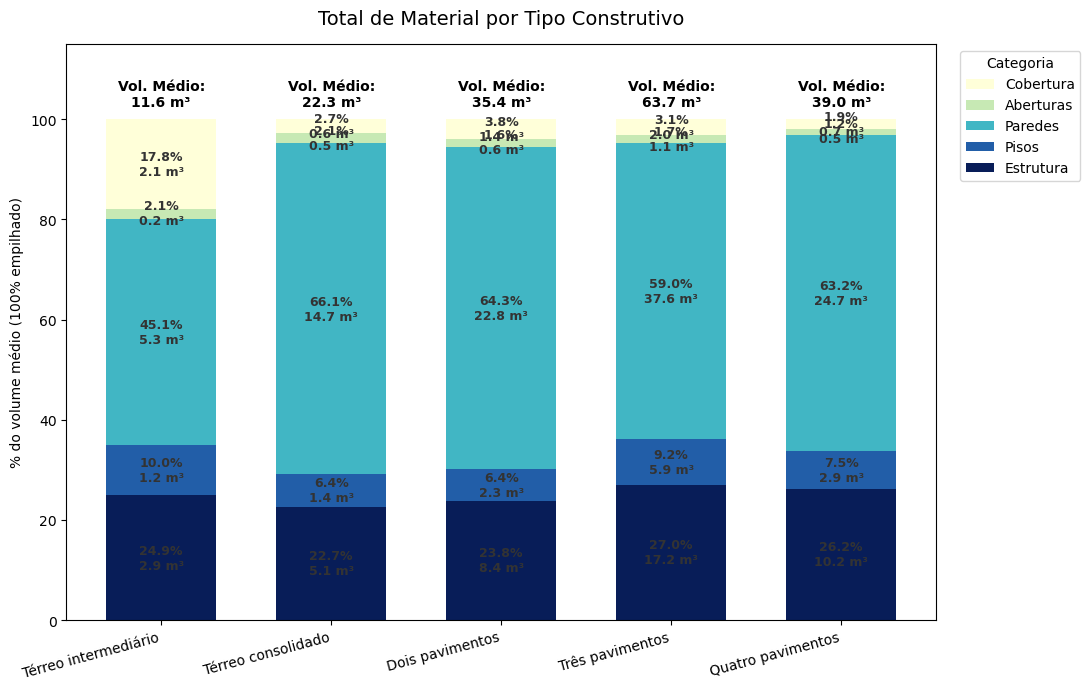

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# ================================================================
# CONFIGURAÇÕES E PARÂMETROS
# ================================================================
path = "/data/interim/consolidado_geral.xlsx"
sheet_name = "QUANTITATIVOS"

# Ordem desejada para o Eixo X (Tipos de Moradia)
tipos_ordem = [
    "Térreo intermediário",
    "Térreo consolidado",
    "Dois pavimentos",
    "Três pavimentos",
    "Quatro pavimentos"
]

# Ordem das pilhas (Categorias)
categoria_ordem = ["Estrutura", "Pisos", "Paredes", "Aberturas", "Cobertura"]
legenda_ordem = ["Cobertura", "Aberturas", "Paredes", "Pisos", "Estrutura"]  # Ordem na legenda (inversa da pilha)

# Regras para rótulos
min_pct_to_label = 2.0     # % mínima para exibir rótulo
min_m3_to_label = 0.05     # volume mínimo para exibir rótulo
fmt_pct = "{:.1f}%"
fmt_m3  = "{:.1f} m³"

# ================================================================
# 1. LEITURA E LIMPEZA
# ================================================================
dq = pd.read_excel(path, sheet_name=sheet_name)
dq.columns = [c.strip() for c in dq.columns] # Remove espaços extras dos nomes das colunas

# ================================================================
# 2. MAPEAMENTO DOS TIPOS
# ================================================================
# Definição dos grupos conforme solicitado
config_tipos = {
    'Térreo intermediário': ['P1A14', 'P1P15'],
    'Térreo consolidado':   ['R1A04', 'V1A16', 'V1P20', 'V1P21'],
    'Dois pavimentos':      ['P2P05', 'C2P10', 'C2P11', 'P2P29', 'V2P32', 'V2P03', 'V2P35'],
    'Três pavimentos':      ['R3A02', 'R3P18', 'V3P24', 'R3P39'],
    'Quatro pavimentos':    ['R4P38']
}

# Criar dicionário reverso (ID -> Tipo) para mapear o DataFrame
map_id_para_tipo = {}
for tipo, lista_ids in config_tipos.items():
    for id_moradia in lista_ids:
        map_id_para_tipo[id_moradia] = tipo

# Filtrar apenas as moradias que estão no nosso dicionário
dq = dq[dq["id_moradia"].isin(map_id_para_tipo.keys())].copy()

# Criar a coluna 'Tipo'
dq["Tipo"] = dq["id_moradia"].map(map_id_para_tipo)


# ===== Mapeamento de categoria =====
def map_categoria(cat):
    if isinstance(cat, str):
        cat_stripped = " ".join(cat.split()).strip()
        if cat_stripped in ["Janelas", "Portas"]:              return "Aberturas"
        if cat_stripped in ["Quadro estrutural", "Escadas"]:   return "Estrutura"
        if cat_stripped in ["Pisos", "Paredes", "Cobertura"]:  return cat_stripped
        #if cat_stripped == "Telhados":                         return "Cobertura"
    return "Outros"

dq["categoria_grp"] = dq["categoria_dicionario"].apply(map_categoria)


# ================================================================
# 3. AGREGAÇÃO (CÁLCULO DA MÉDIA POR TIPO)
# ================================================================

# Passo A: Somar o volume de cada categoria DENTRO de cada casa individualmente
# (Garante que se houver 2 linhas de 'Paredes' para a casa P1A14, elas sejam somadas antes da média)
df_por_casa = (
    dq.groupby(["Tipo", "id_moradia", "categoria_grp"], as_index=False)["volume_bim"]
    .sum()
)

# Passo B: Calcular a MÉDIA dos volumes por Tipo e Categoria
agg = (
    df_por_casa.groupby(["Tipo", "categoria_grp"], as_index=False)["volume_bim"]
    .mean()
    .rename(columns={"volume_bim": "volume_medio"})
)

# ================================================================
# 4. PIVOT E CÁLCULO DE PORCENTAGENS
# ================================================================
pivot = agg.pivot(index="categoria_grp", columns="Tipo", values="volume_medio").fillna(0.0)

# Garante a ordem das colunas (Tipos) conforme lista definida no início
for tipo in tipos_ordem:
    if tipo not in pivot.columns:
        pivot[tipo] = 0.0
pivot = pivot[tipos_ordem]

# Percentual por coluna (100% stacked)
col_sums = pivot.sum(axis=0).replace(0, np.nan)
pct = (pivot / col_sums) * 100.0
pct = pct.fillna(0.0)

# Ordenar as linhas (Categorias)
if categoria_ordem:
    # Filtra apenas as que existem nos dados para evitar erro
    cat_validas = [c for c in categoria_ordem if c in pct.index]
    # Adiciona as que sobraram (se houver) no final
    cat_extras = [c for c in pct.index if c not in cat_validas]
    cat_order = cat_validas + cat_extras
else:
    cat_order = pct.mean(axis=1).sort_values(ascending=False).index.tolist()

pct = pct.loc[cat_order]
pivot = pivot.loc[cat_order]

# ================================================================
# 5. PLOTAGEM
# ================================================================
n_cat = len(pct.index)
# Usando colormap (ajuste o nome se necessário, ex: "GnBu", "viridis", etc)
cmap = cm.get_cmap("YlGnBu_r", n_cat)
cores_categorias = [mcolors.to_hex(cmap(i)) for i in range(n_cat)]

fig, ax = plt.subplots(figsize=(11, 7))

x = np.arange(len(tipos_ordem))
bar_width = 0.65 # Barras um pouco mais finas para caber os nomes longos
bottom = np.zeros(len(tipos_ordem))

for idx, cat in enumerate(pct.index):
    heights_pct = pct.loc[cat].values
    heights_abs = pivot.loc[cat].values

    ax.bar(
        x, heights_pct, bar_width, bottom=bottom,
        label=cat, color=cores_categorias[idx]
    )

    # Rótulos no meio do segmento
    mids = bottom + heights_pct / 2.0
    for i in range(len(x)):
        p = heights_pct[i]
        v = heights_abs[i]

        # Só mostra rótulo se % e volume forem relevantes
        #if p >= min_pct_to_label and v >= min_m3_to_label:
        label = f"{fmt_pct.format(p)}\n{fmt_m3.format(v)}"
        # Cor do texto inteligente (branco se a barra for muito escura, preto caso contrário)
        # Para simplificar, usaremos preto ou cinza escuro aqui, mas pode ajustar
        ax.text(x[i], mids[i], label, ha="center", va="center", fontsize=9, color="#333333", fontweight='bold')

    bottom += heights_pct

# === RÓTULO DO VOLUME TOTAL MÉDIO NO TOPO ===
for i, tipo in enumerate(tipos_ordem):
    total_m3 = col_sums[tipo]
    ax.text(
        x[i], 102,
        f"Vol. Médio:\n{total_m3:.1f} m³",
        ha="center", va="bottom",
        fontsize=10, fontweight="bold", color="black"
    )

# ================================================================
# 6. ESTÉTICA FINAL
# ================================================================
ax.set_xticks(x)
# Rótulos do eixo X com leve rotação para não encavalar
ax.set_xticklabels(tipos_ordem, rotation=15, ha="right")

ax.set_ylim(0, 115) # Aumentei um pouco para caber o título "Vol. Médio"
ax.set_ylabel("% do volume médio (100% empilhado)")
ax.set_title("Total de Material por Tipo Construtivo", y=1.02, fontsize=14)

# Legenda customizada
handles, labels = ax.get_legend_handles_labels()
handle_dict = dict(zip(labels, handles))
ordered_handles = [handle_dict[c] for c in legenda_ordem if c in handle_dict]
ordered_labels  = [c for c in legenda_ordem if c in handle_dict]

ax.legend(
    ordered_handles, ordered_labels,
    title="Categoria",
    bbox_to_anchor=(1.02, 1), loc="upper left"
)

plt.tight_layout()

# Salvar
plt.savefig("grafico_empilhado_medias_por_tipo.png", dpi=160, bbox_inches="tight")
plt.savefig("grafico_empilhado_medias_por_tipo.svg", dpi=160, bbox_inches="tight")

print("Gráfico gerado com sucesso!")
plt.show()

## Índice de intensidade estrutural por tipologia

Aço, cimento, CO₂ e custo por m² em função do número de pavimentos. Pontos
claros = casas individuais; pontos sólidos = média da tipologia; linha tracejada
= regressão linear. **A linha de tendência exclui o "térreo intermediário"**,
por representar um estágio construtivo não comparável às demais tipologias
consolidadas.

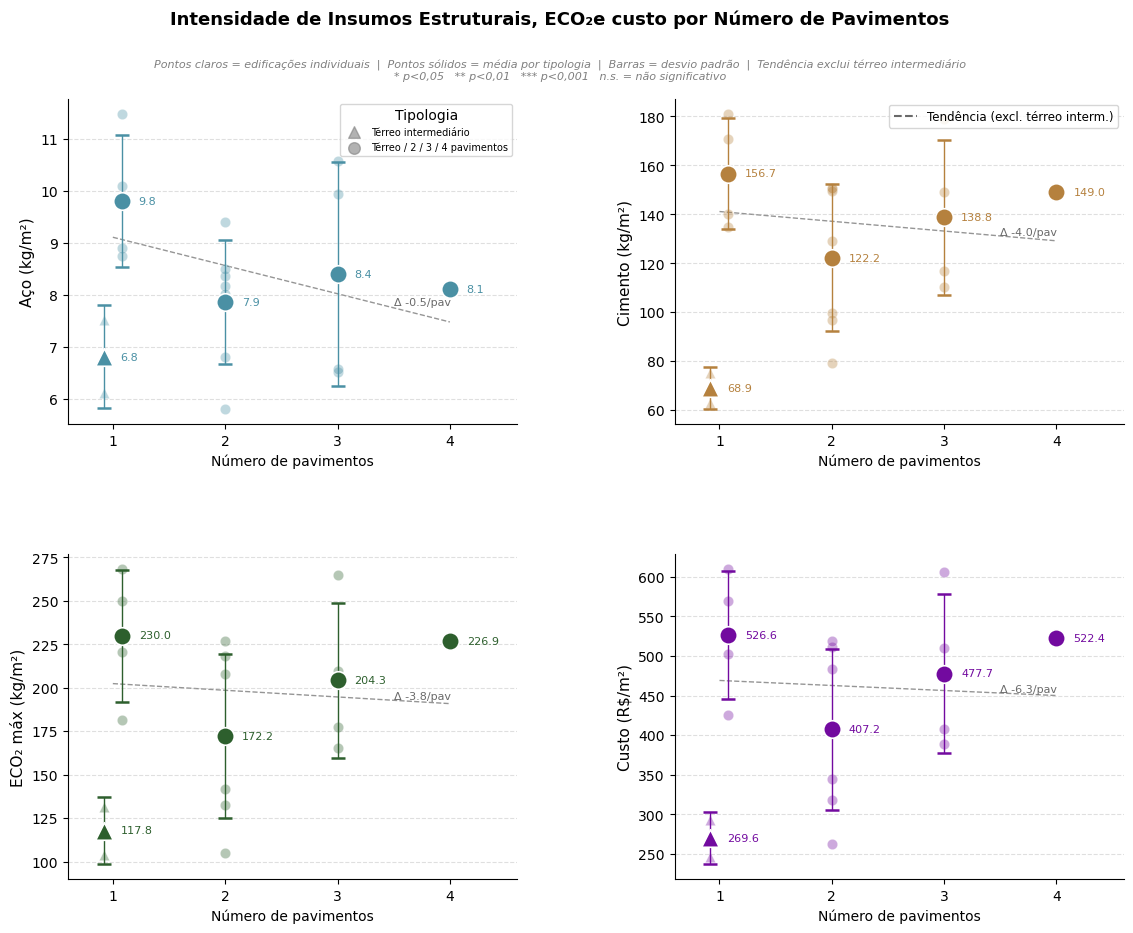

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from scipy import stats

# ==============================================================================
# 1. CARREGAR E PREPARAR DADOS
# ==============================================================================
df = pd.read_excel("/data/interim/consolidado_geral.xlsx", sheet_name="Consolidado_Pavimento")

config_tipos = {
    'Térreo intermediário': ['P1A14', 'P1P15'],
    'Térreo consolidado':   ['R1A04', 'V1A16', 'V1P20', 'V1P21'],
    'Dois pavimentos':      ['P2P05', 'C2P10', 'C2P11', 'P2P29', 'V2P32', 'V2P03', 'V2P35'],
    'Três pavimentos':      ['R3A02', 'R3P18', 'V3P24', 'R3P39'],
    'Quatro pavimentos':    ['R4P38']
}
map_id  = {id_m: tipo for tipo, ids in config_tipos.items() for id_m in ids}
n_pav   = {        # número de pavimentos por tipologia (eixo x numérico)
    'Térreo intermediário': 1,
    'Térreo consolidado':   1,
    'Dois pavimentos':      2,
    'Três pavimentos':      3,
    'Quatro pavimentos':    4,
}
df['Tipo'] = df['id_moradia'].map(map_id)
df = df.dropna(subset=['Tipo'])

# ==============================================================================
# 2. AGREGAR POR EDIFICAÇÃO (soma dos pavimentos de cada casa)
# ==============================================================================
df_casa = df.groupby(['id_moradia', 'Tipo']).agg(
    aco_total    =('total_aco_kg',        'sum'),
    cimento_total=('total_cimento_kg',    'sum'),
    area_total   =('area_total_pavimento','sum'),
    co2_max_total=('co2_max',            'sum'),
    custo_total   =('custo_total',        'sum'),
).reset_index()

df_casa['aco_m2']     = df_casa['aco_total']     / df_casa['area_total']
df_casa['cimento_m2'] = df_casa['cimento_total'] / df_casa['area_total']
df_casa['co2_max_m2'] = df_casa['co2_max_total'] / df_casa['area_total']
df_casa['custo_m2']   = df_casa['custo_total']   / df_casa['area_total']
df_casa['n_pav']      = df_casa['Tipo'].map(n_pav)

# ==============================================================================
# 3. MÉDIAS E DESVIOS POR TIPOLOGIA
# ==============================================================================
df_tipo = (df_casa.groupby(['Tipo', 'n_pav'])
           .agg(
               aco_mean    =('aco_m2',     'mean'),
               aco_std     =('aco_m2',     'std'),
               cimento_mean=('cimento_m2', 'mean'),
               cimento_std =('cimento_m2', 'std'),
               co2_mean    =('co2_max_m2', 'mean'),
               co2_std     =('co2_max_m2', 'std'),
                custo_mean   =('custo_m2',   'mean'),
                custo_std    =('custo_m2',   'std'),
               n           =('id_moradia', 'count'),
           )
           .reset_index()
           .sort_values('n_pav'))

# Desvio padrão NaN para n=1 → substituir por 0 para não quebrar o errorbar
df_tipo[['aco_std','cimento_std','co2_std', 'custo_std']] = df_tipo[['aco_std','cimento_std','co2_std', 'custo_std']].fillna(0)

# ==============================================================================
# 4. LINHA DE TENDÊNCIA (regressão linear sobre os pontos individuais das casas)
#    Usa apenas os tipos consolidados (exclui térreo intermediário)
# ==============================================================================
df_tend = df_casa[df_casa['Tipo'] != 'Térreo intermediário'].copy()

def linha_tendencia(x, y):
    slope, intercept, r, p, _ = stats.linregress(x, y)
    x_range = np.linspace(x.min(), x.max(), 100)
    return x_range, intercept + slope * x_range, r**2, p, slope

x_tend = df_tend['n_pav'].values.astype(float)
xt_aco,  yt_aco,  r2_aco,  p_aco,  s_aco  = linha_tendencia(x_tend, df_tend['aco_m2'])
xt_cim,  yt_cim,  r2_cim,  p_cim,  s_cim  = linha_tendencia(x_tend, df_tend['cimento_m2'])
xt_co2,  yt_co2,  r2_co2,  p_co2,  s_co2  = linha_tendencia(x_tend, df_tend['co2_max_m2'])
xt_cust, yt_cust, r2_cust, p_cust, s_cust = linha_tendencia(x_tend, df_tend['custo_m2'])

# ==============================================================================
# 5. CONFIGURAÇÕES VISUAIS — personalize aqui
# ==============================================================================
cor_aco      = '#4a90a4'    # azul-aço
cor_cimento  = '#b5813e'    # ocre-cimento
cor_co2      = '#2d5f2d'    # verde-escuro — ECO2
cor_cust     = "#720a9f"    # roxo-escuro — Custo
cor_tend     = 'dimgray'
alpha_tend   = 0.7

# Marcadores por tipologia
marcadores = {
    'Térreo intermediário': '^',   # triângulo — estágio intermediário
    'Térreo consolidado':   'o',
    'Dois pavimentos':      'o',
    'Três pavimentos':      'o',
    'Quatro pavimentos':    'o',
}
# Deslocamento horizontal leve para tipos no mesmo n_pav (térreos)
jitter = {
    'Térreo intermediário': -0.08,
    'Térreo consolidado':    0.08,
    'Dois pavimentos':       0.0,
    'Três pavimentos':       0.0,
    'Quatro pavimentos':     0.0,
}

# ==============================================================================
# 6. FIGURA: 3 painéis verticais (Aço | Cimento | ECO2 máx)
# ==============================================================================
# Layout 2x2 
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharey=False)
fig.subplots_adjust(left=0.09, right=0.97, top=0.88, bottom=0.10, wspace=0.35, hspace=0.4)
axes = axes.flatten()  # facilita iterar como lista

configs = [
    ('aco_m2',     'aco_mean',    'aco_std',    cor_aco,     xt_aco,  yt_aco,  r2_aco,  p_aco,  s_aco,  'Aço (kg/m²)'),
    ('cimento_m2', 'cimento_mean','cimento_std', cor_cimento, xt_cim,  yt_cim,  r2_cim,  p_cim,  s_cim,  'Cimento (kg/m²)'),
    ('co2_max_m2', 'co2_mean', 'co2_std',           cor_co2,     xt_co2,  yt_co2,  r2_co2,  p_co2,  s_co2,  'ECO₂ máx (kg/m²)'),
    ('custo_m2',   'custo_mean',  'custo_std',   cor_cust,    xt_cust, yt_cust, r2_cust, p_cust, s_cust, 'Custo (R$/m²)'),
]

for ax, (col_ind, col_mean, col_std, cor, xt, yt, r2, p, slope, ylabel) in zip(axes, configs):

    # --- Pontos individuais das casas ---
    for tipo, grupo in df_casa.groupby('Tipo'):
        x_j = grupo['n_pav'] + jitter[tipo]
        ax.scatter(x_j, grupo[col_ind],
                   color=cor, alpha=0.35, s=55,
                   marker=marcadores[tipo], zorder=2,
                   edgecolors='white', linewidths=0.5)

    # --- Médias por tipologia com barra de erro ---
    for _, row in df_tipo.iterrows():
        x_j = row['n_pav'] + jitter[row['Tipo']]
        yerr = row[col_std] if col_std else 0
        ax.errorbar(x_j, row[col_mean], yerr=yerr,
                    fmt='none', color=cor,
                    capsize=5, capthick=1.8, elinewidth=1, zorder=3)
        ax.scatter(x_j, row[col_mean],
                   color=cor, s=160, zorder=4,
                   marker=marcadores[row['Tipo']],
                   edgecolors='white', linewidths=1.2,
                   label=row['Tipo'] if ax == axes[0] else '')
        # Rótulo da média
        ax.text(x_j + 0.15, row[col_mean], f'{row[col_mean]:.1f}',
                va='center', fontsize=8, color=cor)

    # --- Linha de tendência (excluindo térreo intermediário) ---
    ax.plot(xt, yt, color=cor_tend, linewidth=1,
            linestyle='--', alpha=alpha_tend, zorder=1)


    # Seta com o coeficiente angular (variação por pavimento)
    ax.annotate(f'Δ {slope:+.1f}/pav',
                xy=(xt[-1], yt[-1]), xytext=(xt[-1] - 0.5, yt[-1] + abs(slope) * 0.6),
                fontsize=8, color=cor_tend,
               )

    # Formatação
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_xlabel('Número de pavimentos', fontsize=10)
    ax.set_xticks([1, 2, 3, 4])
    ax.set_xlim(0.6, 4.6)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ==============================================================================
# 7. LEGENDA GLOBAL E TÍTULOS
# ==============================================================================
# Legenda de tipologia (marcador)
leg_tipos = [
    plt.scatter([], [], marker='^', color='gray', alpha=0.6, s=70,
                label='Térreo intermediário'),
    plt.scatter([], [], marker='o', color='gray', alpha=0.6, s=70,
                label='Térreo / 2 / 3 / 4 pavimentos'),
]
leg1 = axes[0].legend(handles=leg_tipos, loc='upper right',
                       fontsize=7, framealpha=0.8, title='Tipologia')

# Legenda linha de tendência
leg2_handle = plt.Line2D([0],[0], linestyle='--', color=cor_tend,
                          linewidth=1.5, label='Tendência (excl. térreo interm.)')
axes[1].legend(handles=[leg2_handle], loc='upper right',
               fontsize=8.5, framealpha=0.8)

fig.suptitle('Intensidade de Insumos Estruturais, ECO₂e custo por Número de Pavimentos',
             fontsize=13, fontweight='bold', y=0.97)
fig.text(0.5, 0.90,
         'Pontos claros = edificações individuais  |  Pontos sólidos = média por tipologia  '
         '|  Barras = desvio padrão  |  Tendência exclui térreo intermediário\n'
         '* p<0,05   ** p<0,01   *** p<0,001   n.s. = não significativo',
         ha='center', fontsize=8, color='gray', style='italic')

plt.savefig("grafico_intensidade_estrutural.png", bbox_inches='tight', dpi=150)
plt.show()

## Análise por nível/pavimento

Os gráficos a seguir usam o **pavimento individual** como unidade amostral — cada
linha de `Consolidado_Pavimento` é um pavimento já normalizado por área, e as
estatísticas são calculadas sobre esse conjunto, sem somar por edificação.

> **Amostra deste bloco: n=39.** Inclui todas as moradias visitadas,
> mesmo aquelas em que apenas um pavimento de uma edificação de múltiplos andares
> foi medido. Como a análise é por nível, esses pavimentos parciais são
> observações válidas, por isso o n maior.
>
> **Contraste com o bloco "Análise por tipo construtivo" (n=19).** Lá a unidade
> amostral é a **casa**, e só entram as 19 moradias medidas **integralmente** —
> as únicas em que faz sentido somar os pavimentos para obter o total da
> edificação. Os dois blocos respondem a perguntas diferentes, sobre amostras
> diferentes, e não são diretamente comparáveis.

## CO₂ médio por nível de pavimento

Faixa de emissão (mín–máx) de CO₂ por m² para cada nível — Térreo a Pavimento 3.
Pontos = média das casas naquele nível; barras = IC 95% por bootstrap percentil
(2000 reamostragens). Níveis com uma única observação (n=1) não recebem IC e são
marcados com `*`. A faixa sombreada liga o IC do mínimo ao IC do máximo,
representando o envelope de incerteza combinado.

Unidade amostral: pavimento individual. **Não** inclui a incerteza dos fatores de
emissão — apenas a variabilidade amostral entre pavimentos.

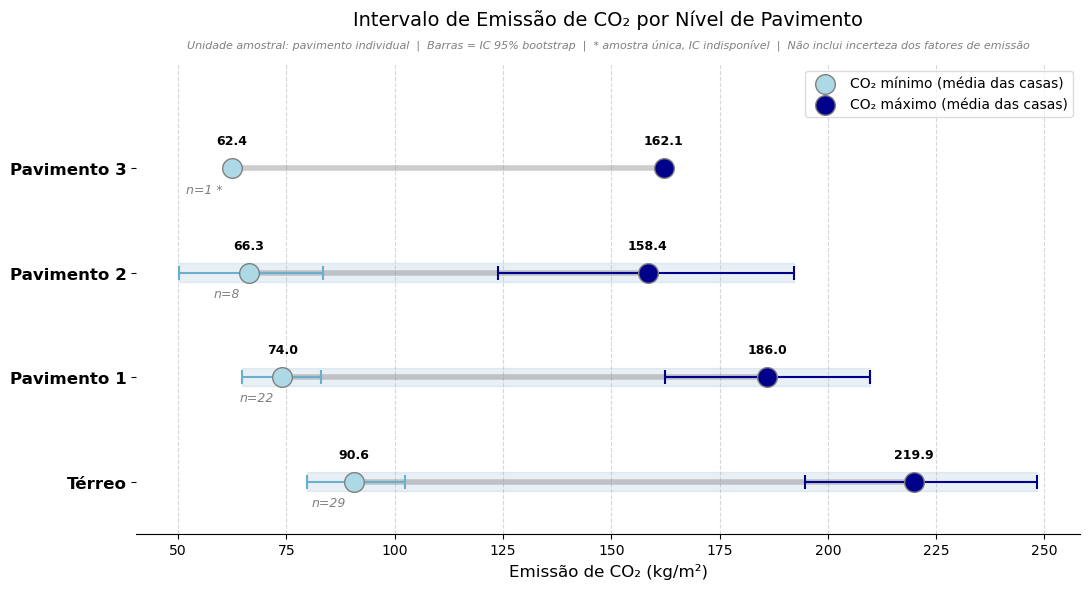

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ==============================================================================
# 1. CARREGAR DADOS
# ==============================================================================
df = pd.read_excel("/data/interim/consolidado_geral.xlsx",
                   sheet_name="Consolidado_Pavimento")

# ==============================================================================
# 2. AGRUPAMENTO POR PAVIMENTO (unidade amostral = pavimento individual)
#    Sem somar — cada linha já é um pavimento normalizado por área
# ==============================================================================

# Mapeamento de nível do pavimento para ordenação
ordem_pavimentos = ['TÉRREO', 'PAVIMENTO 1', 'PAVIMENTO 2', 'PAVIMENTO 3']
label_pavimentos = {
    'TÉRREO':      'Térreo',
    'PAVIMENTO 1': 'Pavimento 1',
    'PAVIMENTO 2': 'Pavimento 2',
    'PAVIMENTO 3': 'Pavimento 3',
}

# Filtrar apenas pavimentos presentes nos dados e na ordem desejada
df_pav = df[df['pavimento_bim'].isin(ordem_pavimentos)].copy()
df_pav['nivel'] = df_pav['pavimento_bim'].map(label_pavimentos)

# ==============================================================================
# 3. BOOTSTRAP POR NÍVEL DE PAVIMENTO
# ==============================================================================

def bootstrap_ci(data, n_boot=2000, ci=95, seed=42):
    """
    Retorna (média, limite_inferior, limite_superior) via bootstrap percentil.
    Com n < 2, retorna NaN nos limites (sem IC para amostra única).
    """
    data = data.dropna().values
    n = len(data)
    if n < 2:
        return np.mean(data), np.nan, np.nan
    rng = np.random.default_rng(seed)
    boots = [np.mean(rng.choice(data, size=n, replace=True)) for _ in range(n_boot)]
    lower = np.percentile(boots, (100 - ci) / 2)
    upper = np.percentile(boots, 100 - (100 - ci) / 2)
    return np.mean(data), lower, upper

rows = []
for nivel_raw in ordem_pavimentos:
    label = label_pavimentos[nivel_raw]
    sub = df_pav[df_pav['pavimento_bim'] == nivel_raw]
    n_obs = len(sub)

    min_mean, min_lo, min_hi = bootstrap_ci(sub['CO2 mínimo (kg/m2)'])
    max_mean, max_lo, max_hi = bootstrap_ci(sub['CO2 máximo (kg/m2)'])

    sub_mid = (sub['CO2 mínimo (kg/m2)'] + sub['CO2 máximo (kg/m2)']) / 2
    mid_mean, mid_lo, mid_hi = bootstrap_ci(sub_mid)

    rows.append({
        'Tipo': label, 'n': n_obs,
        'min_mean': min_mean, 'min_lo': min_lo, 'min_hi': min_hi,
        'max_mean': max_mean, 'max_lo': max_lo, 'max_hi': max_hi,
        'mid_mean': mid_mean, 'mid_lo': mid_lo, 'mid_hi': mid_hi,
    })

df_stats = pd.DataFrame(rows)


# ==============================================================================
# 5. PLOTAGEM
# ==============================================================================
fig, ax = plt.subplots(figsize=(11, 6))

cor_min   = '#add8e6'
cor_max   = '#00008b'
cor_mid   = '#4a90a4'
cor_linha = 'grey'

y_pos    = list(range(len(df_stats)))
nomes    = df_stats['Tipo']
vals_min = df_stats['min_mean']
vals_max = df_stats['max_mean']
vals_mid = df_stats['mid_mean']

# --- Erros assimétricos [distância abaixo, distância acima] ---
def erros(df, col):
    lo = (df[f'{col}_mean'] - df[f'{col}_lo']).fillna(0)
    hi = (df[f'{col}_hi']   - df[f'{col}_mean']).fillna(0)
    return [lo, hi]

err_min = erros(df_stats, 'min')
err_max = erros(df_stats, 'max')
err_mid = erros(df_stats, 'mid')

# 1. Linha conectora (entre médias dos extremos)
ax.hlines(y=y_pos, xmin=vals_min, xmax=vals_max,
          color=cor_linha, alpha=0.4, linewidth=4)

# 2. Faixa sombreada: envelope de incerteza combinado (IC boot do min ao IC boot do max)
for i in y_pos:
    lo = df_stats['min_lo'].iloc[i]
    hi = df_stats['max_hi'].iloc[i]
    if not (np.isnan(lo) or np.isnan(hi)):
        ax.fill_betweenx([i - 0.09, i + 0.09], lo, hi,
                         color='steelblue', alpha=0.12, zorder=1)

# 3. Barras de erro nos três pontos
ax.errorbar(vals_min, y_pos, xerr=err_min,
            fmt='none', color='#6ab0cc',
            capsize=5, capthick=1.5, elinewidth=1.5, zorder=2)

ax.errorbar(vals_max, y_pos, xerr=err_max,
            fmt='none', color='#00008b',
            capsize=5, capthick=1.5, elinewidth=1.5, zorder=2)

#ax.errorbar(vals_mid, y_pos, xerr=err_mid,
#            fmt='none', color=cor_mid,
#            capsize=4, capthick=1.2, elinewidth=1.2, zorder=2)

# 4. Pontos
ax.scatter(vals_min, y_pos, color=cor_min, s=200, zorder=3,
           edgecolors='gray', label='CO₂ mínimo (média das casas)')
ax.scatter(vals_max, y_pos, color=cor_max, s=200, zorder=3,
           edgecolors='gray', label='CO₂ máximo (média das casas)')
#ax.scatter(vals_mid, y_pos, color=cor_mid, s=80,  zorder=4,
#           edgecolors='white', linewidths=0.8,
#           marker='D', label='Ponto central [(min+max)/2]')

# 5. Rótulos de valor nos extremos
offset_y = 0.20
for i in y_pos:
    ax.text(vals_min.iloc[i], i + offset_y, f'{vals_min.iloc[i]:.1f}',
            ha='center', va='bottom', color='black', fontsize=9, fontweight='bold')
    ax.text(vals_max.iloc[i], i + offset_y, f'{vals_max.iloc[i]:.1f}',
            ha='center', va='bottom', color='black', fontsize=9, fontweight='bold')

# 6. n amostral à esquerda (indica casas com IC ausente)
x_left = ax.get_xlim()[0] if ax.get_xlim()[0] != 0 else vals_min.min() - 20
for i in y_pos:
    n = df_stats['n'].iloc[i]
    sem_ic = df_stats['min_lo'].isna().iloc[i]
    label = f'n={n}' + (' *' if sem_ic else '')
    ax.text(vals_min.iloc[i] - 2, i-0.20, label,
            ha='right', va='center', color='gray', fontsize=9, style='italic')

# ==============================================================================
# 6. FORMATAÇÃO
# ==============================================================================
ax.set_yticks(y_pos)
ax.set_yticklabels(nomes, fontsize=12, fontweight='bold')
ax.set_xlabel('Emissão de CO₂ (kg/m²)', fontsize=12)
ax.set_title('Intervalo de Emissão de CO₂ por Nível de Pavimento', fontsize=14, pad=28)

# Subtítulo com nota metodológica
ax.text(0.5, 1.03,
        'Unidade amostral: pavimento individual  |  Barras = IC 95% bootstrap  |  '
        '* amostra única, IC indisponível  |  Não inclui incerteza dos fatores de emissão',
        transform=ax.transAxes, ha='center', va='bottom',
        fontsize=8, color='gray', style='italic')

ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_ylim(-0.5, len(df_stats) - 1 + 1.0)
ax.legend(loc='upper right', fontsize=10, framealpha=0.7)

plt.tight_layout()
plt.savefig("dumbbell_co2_bootstrap_pavimentos.png", bbox_inches='tight', dpi=150)
plt.show()

## Participação dos materiais por nível de pavimento

Um painel por nível (Térreo a Pavimento 3), mostrando a participação % média de
cada insumo no CO₂ total daquele pavimento (barras pareadas mín/máx, com desvio
padrão entre pavimentos). Insumos ordenados por amplitude crescente do fator de
emissão. Insumos ausentes num nível (ex.: lajota de enchimento no térreo)
simplesmente não têm barra naquele painel.

Unidade amostral: pavimento individual. O `n` no título de cada painel indica
quantas moradias contribuíram para aquele nível.

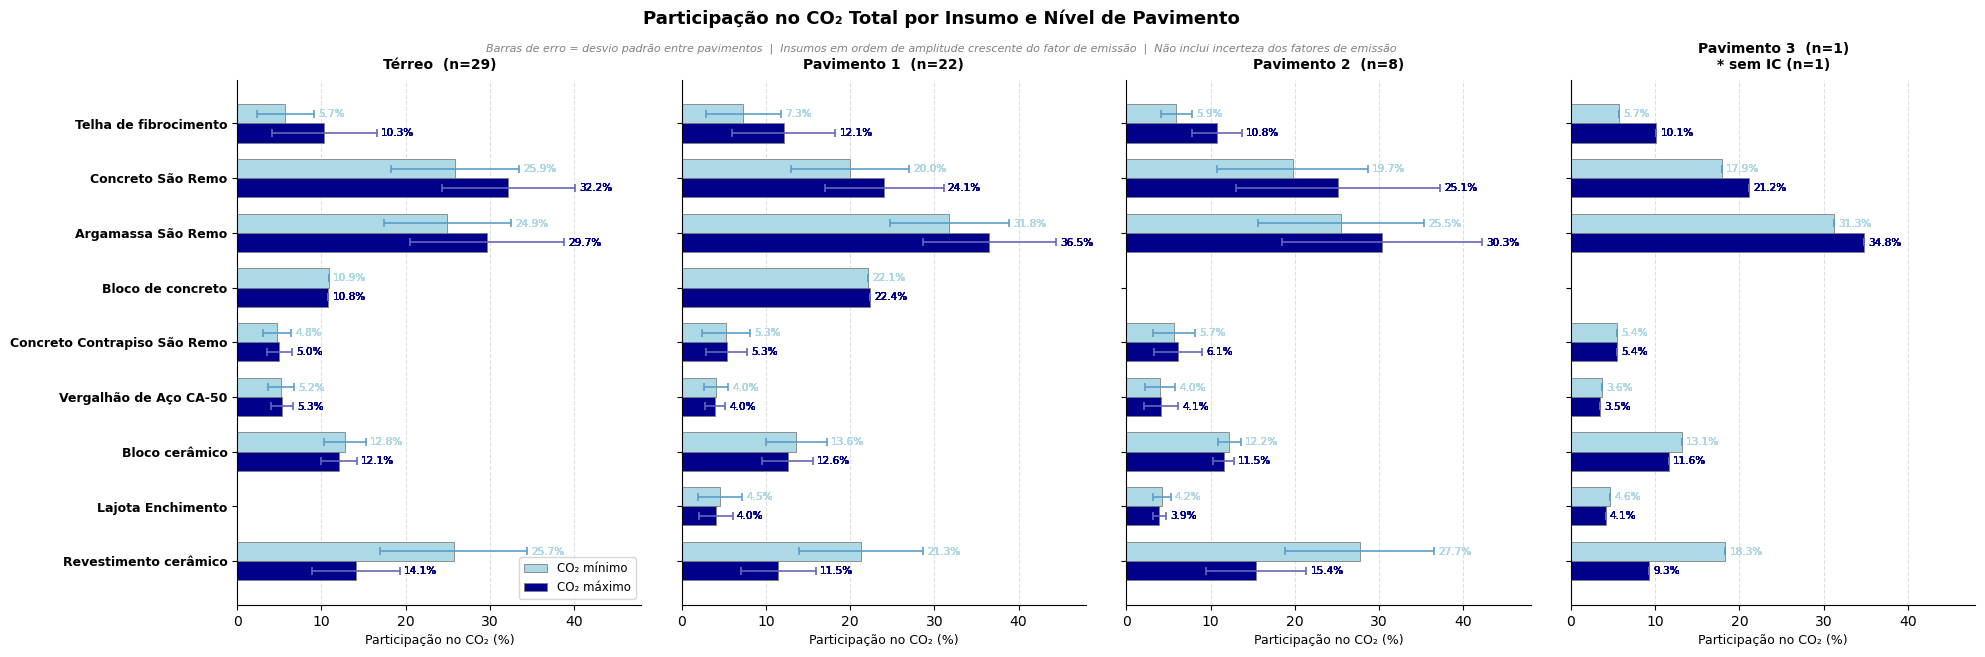

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ==============================================================================
# 1. CARREGAR DADOS
# ==============================================================================
df_quant = pd.read_excel("/data/interim/consolidado_geral.xlsx",
                         sheet_name="QUANTITATIVOS")
df_pav   = pd.read_excel("/data/interim/consolidado_geral.xlsx",
                         sheet_name="Consolidado_Pavimento")
df_fe    = pd.read_excel("/data/external/DIM_FATORES_EMISSAO.xlsx")

# ==============================================================================
# 2. FILTRAR PAVIMENTOS RELEVANTES — todas as moradias, sem filtro de tipologia
# ==============================================================================
ordem_pavimentos  = ['TÉRREO', 'PAVIMENTO 1', 'PAVIMENTO 2', 'PAVIMENTO 3']
labels_pavimentos = ['Térreo', 'Pavimento 1', 'Pavimento 2', 'Pavimento 3']

df_quant_pav = df_quant[df_quant['pavimento_bim'].isin(ordem_pavimentos)].copy()

# ==============================================================================
# 3. CONTRIBUIÇÃO DE CO2 POR INSUMO POR PAVIMENTO INDIVIDUAL
# ==============================================================================
df_contrib = (df_quant_pav.dropna(subset=['co2_min', 'co2_max'])
              .groupby(['id_moradia', 'pavimento_bim', 'insumo'])[['co2_min', 'co2_max']]
              .sum().reset_index())

# Área por pavimento individual
df_area_pav = (df_pav[df_pav['pavimento_bim'].isin(ordem_pavimentos)]
               [['id_moradia', 'pavimento_bim', 'area_total_pavimento']].copy())
df_contrib = df_contrib.merge(df_area_pav, on=['id_moradia', 'pavimento_bim'])
df_contrib['co2_min_m2'] = df_contrib['co2_min'] / df_contrib['area_total_pavimento']
df_contrib['co2_max_m2'] = df_contrib['co2_max'] / df_contrib['area_total_pavimento']

# Participação % no total de cada pavimento
df_total = (df_contrib.groupby(['id_moradia', 'pavimento_bim'])[['co2_min_m2', 'co2_max_m2']]
            .sum().reset_index())
df_total.columns = ['id_moradia', 'pavimento_bim', 'total_min', 'total_max']
df_contrib = df_contrib.merge(df_total, on=['id_moradia', 'pavimento_bim'])
df_contrib['pct_min'] = df_contrib['co2_min_m2'] / df_contrib['total_min'] * 100
df_contrib['pct_max'] = df_contrib['co2_max_m2'] / df_contrib['total_max'] * 100

# ==============================================================================
# 4. ORDEM DOS INSUMOS (amplitude crescente do fator de emissão)
#    Lajota Enchimento incluída na ordem mas ausente no térreo — sem problema,
#    o categorical simplesmente não vai plotar a barra naquele painel
# ==============================================================================
df_fe = df_fe.dropna(subset=['fator_emissao_min', 'fator_emissao_max']).copy()
df_fe['fator_emissao_min'] = df_fe['fator_emissao_min'].astype(float)
df_fe['fator_emissao_max'] = df_fe['fator_emissao_max'].astype(float)
df_fe['amplitude_rel'] = ((df_fe['fator_emissao_max'] - df_fe['fator_emissao_min'])
                          / df_fe['fator_emissao_min'] * 100)
df_fe = df_fe.sort_values('amplitude_rel', ascending=True).reset_index(drop=True)
ordem_insumos = df_fe['insumo'].tolist()

# ==============================================================================
# 5. AGREGAR POR INSUMO PARA CADA NÍVEL DE PAVIMENTO
# ==============================================================================
niveis_presentes = [n for n in ordem_pavimentos
                    if n in df_contrib['pavimento_bim'].unique()]
labels_presentes = [labels_pavimentos[ordem_pavimentos.index(n)]
                    for n in niveis_presentes]

todos_insumos = [i for i in ordem_insumos if i in df_contrib['insumo'].unique()]

dfs_nivel = {}
for nivel in niveis_presentes:
    sub = df_contrib[df_contrib['pavimento_bim'] == nivel]
    df_b_n = (sub.groupby('insumo')
              .agg(
                  pct_min_mean=('pct_min',    'mean'),
                  pct_min_std =('pct_min',    'std'),
                  pct_max_mean=('pct_max',    'mean'),
                  pct_max_std =('pct_max',    'std'),
                  cv_max      =('co2_max_m2', lambda x: x.std() / x.mean() * 100),
                  n_obs       =('co2_max_m2', 'count'),
              )
              .reset_index())

    # Reindexar para incluir TODOS os insumos — ausentes ficam NaN
    df_b_n = (df_b_n.set_index('insumo')
              .reindex(todos_insumos)
              .reset_index())
    df_b_n.columns = ['insumo'] + list(df_b_n.columns[1:])
    dfs_nivel[nivel] = df_b_n

# ==============================================================================
# 6. CONFIGURAÇÕES VISUAIS
# ==============================================================================
cor_min   = '#add8e6'
cor_max   = '#00008b'
altura    = 0.35
n_paineis = len(niveis_presentes)

# ==============================================================================
# 7. FIGURA: um painel por nível de pavimento
# ==============================================================================
fig, axes = plt.subplots(1, n_paineis,
                          figsize=(5.5 * n_paineis, 7),
                          sharey=True)   # ← de volta para True
fig.subplots_adjust(left=0.18, right=0.97, top=0.87, bottom=0.12, wspace=0.10)

if n_paineis == 1:
    axes = [axes]

for ax, nivel, label in zip(axes, niveis_presentes, labels_presentes):
    df_b  = dfs_nivel[nivel]
    y_pos = np.arange(len(df_b))
    n_obs = df_contrib[df_contrib['pavimento_bim'] == nivel]['id_moradia'].nunique()

    # Barras — pular linhas com NaN (insumo ausente neste nível)
    label_min_adicionado = False
    label_max_adicionado = False

    for i, row in df_b.iterrows():
        if pd.isna(row['pct_min_mean']):
            continue

        lbl_min = 'CO₂ mínimo' if not label_min_adicionado else ''
        lbl_max = 'CO₂ máximo' if not label_max_adicionado else ''

        ax.barh(i + altura/2, row['pct_min_mean'],
                height=altura, color=cor_min, edgecolor='gray',
                linewidth=0.6, label=lbl_min, zorder=2)
        ax.barh(i - altura/2, row['pct_max_mean'],
                height=altura, color=cor_max, edgecolor='gray',
                linewidth=0.6, label=lbl_max, zorder=2)
        ax.errorbar(row['pct_min_mean'], i + altura/2,
                    xerr=row['pct_min_std'] if pd.notna(row['pct_min_std']) else 0,
                    fmt='none', color='#5a9ec9',
                    capsize=3, capthick=1.2, elinewidth=1.2, zorder=3)
        ax.errorbar(row['pct_max_mean'], i - altura/2,
                    xerr=row['pct_max_std'] if pd.notna(row['pct_max_std']) else 0,
                    fmt='none', color='#6666bb',
                    capsize=3, capthick=1.2, elinewidth=1.2, zorder=3)

        label_min_adicionado = True
        label_max_adicionado = True

    # Rótulos do CO₂ máximo

        for i, row in df_b.iterrows():
            if pd.isna(row['pct_max_mean']):
                continue
            offset = row['pct_max_std'] + 0.5 if pd.notna(row['pct_max_std']) else 0.5
            ax.text(row['pct_max_mean'] + offset, i - altura/2,
                    f'{row["pct_max_mean"]:.1f}%',
                    va='center', fontsize=7.5, color=cor_max)
            
        # Rótulos do CO₂ mínimo

        for i, row in df_b.iterrows():
            if pd.isna(row['pct_min_mean']):
                continue
            offset = row['pct_min_std'] + 0.5 if pd.notna(row['pct_min_std']) else 0.5
            ax.text(row['pct_min_mean'] + offset, i + altura/2,
                    f'{row["pct_min_mean"]:.1f}%',
                    va='center', fontsize=7.5, color=cor_min)


    # Eixo Y: rótulos só no primeiro painel
    ax.set_yticks(y_pos)
    # Eixo Y: rótulos em TODOS os painéis
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df_b['insumo'], fontsize=9, fontweight='bold')
    #ax.tick_params(axis='y', which='both', labelleft=True)
    ax.spines['left'].set_visible(True)

    nota_ic = '\n* sem IC (n=1)' if n_obs == 1 else ''
    ax.set_title(f'{label}  (n={n_obs}){nota_ic}',
                 fontsize=10, fontweight='bold', pad=8)
    ax.set_xlabel('Participação no CO₂ (%)', fontsize=9)
    ax.set_xlim(0, 48)
    ax.set_ylim(-0.8, len(df_b) - 0.2)
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].legend(loc='lower right', fontsize=8.5, framealpha=0.8)

# ==============================================================================
# 8. TÍTULOS E NOTAS
# ==============================================================================
fig.suptitle('Participação no CO₂ Total por Insumo e Nível de Pavimento',
             fontsize=13, fontweight='bold', y=0.97)
fig.text(0.5, 0.91,
         'Barras de erro = desvio padrão entre pavimentos  |  '
         'Insumos em ordem de amplitude crescente do fator de emissão  |  '
         'Não inclui incerteza dos fatores de emissão',
         ha='center', fontsize=8, color='gray', style='italic')

plt.savefig("grafico_B_por_pavimento.png", bbox_inches='tight', dpi=150)
plt.show()

## Intensidade de materiais e custo por nível de pavimento

Aço, cimento, CO₂ máximo e custo por m² em função do nível do pavimento, em
quatro painéis. Pontos claros = pavimentos individuais (com leve jitter
horizontal para separar sobreposições); pontos sólidos = média do nível; barras
= desvio padrão; linha tracejada = regressão linear sobre todos os pavimentos.
Cada painel reporta R² e significância (`*` p<0,05, `**` p<0,01, `***` p<0,001,
`n.s.` não significativo) e o coeficiente angular (Δ por pavimento).

Unidade amostral: pavimento individual (**n=39** — todos os pavimentos medidos,
incluindo os de edificações não medidas integralmente). Ao contrário da regressão
do bloco por tipologia, esta **não** exclui nenhum nível.

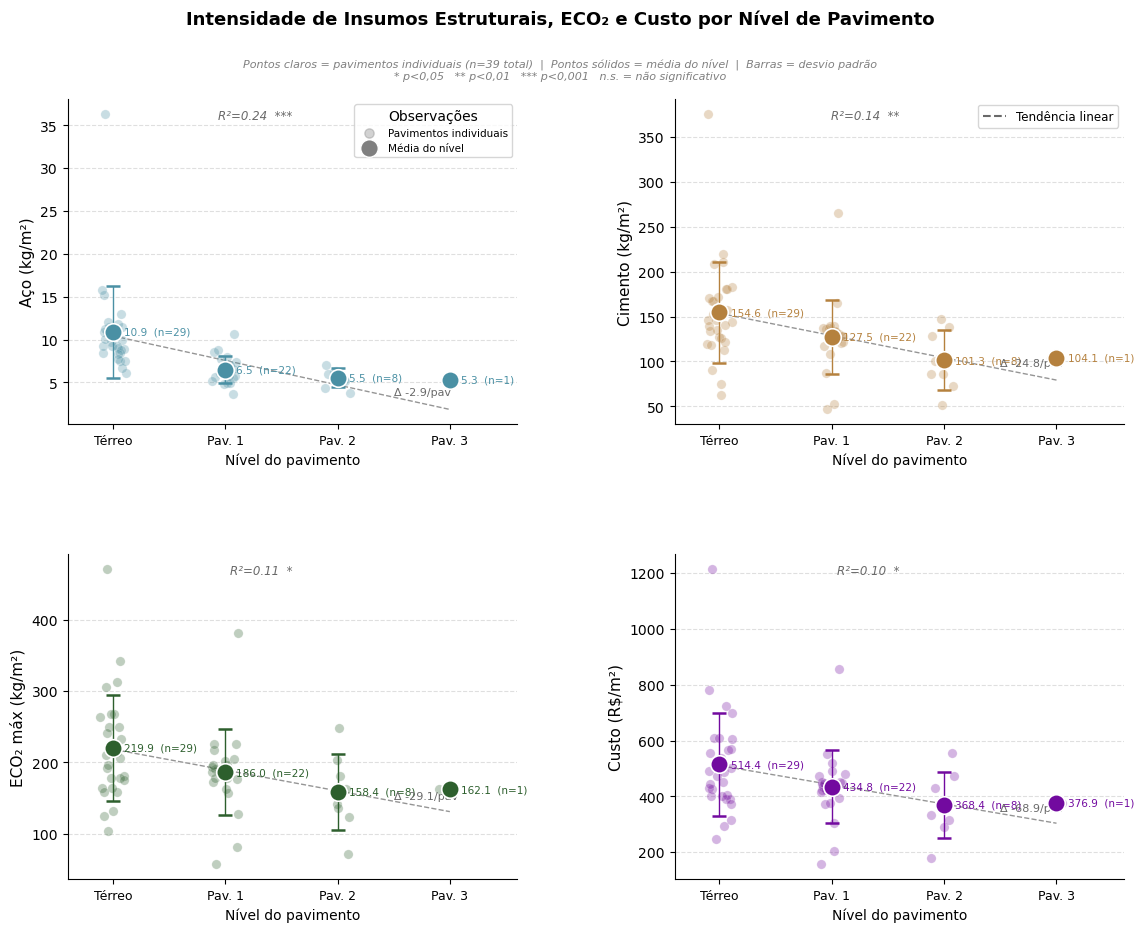

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from scipy import stats

# ==============================================================================
# 1. CARREGAR E PREPARAR DADOS
# ==============================================================================
df = pd.read_excel("/data/interim/consolidado_geral.xlsx",
                   sheet_name="Consolidado_Pavimento")

# ==============================================================================
# 2. FILTRAR E MAPEAR NÍVEL DO PAVIMENTO
#    Unidade amostral = pavimento individual — todas as 39 moradias
# ==============================================================================
ordem_pavimentos  = ['TÉRREO', 'PAVIMENTO 1', 'PAVIMENTO 2', 'PAVIMENTO 3']
n_pav_map         = {'TÉRREO': 1, 'PAVIMENTO 1': 2, 'PAVIMENTO 2': 3, 'PAVIMENTO 3': 4}
label_pav_map     = {'TÉRREO': 'Térreo', 'PAVIMENTO 1': 'Pav. 1',
                     'PAVIMENTO 2': 'Pav. 2', 'PAVIMENTO 3': 'Pav. 3'}

df_pav = df[df['pavimento_bim'].isin(ordem_pavimentos)].copy()
df_pav['n_pav']  = df_pav['pavimento_bim'].map(n_pav_map)
df_pav['label']  = df_pav['pavimento_bim'].map(label_pav_map)

# Métricas já normalizadas por m² na planilha
# Renomear para consistência com o código anterior
df_pav = df_pav.rename(columns={
    'Aço (kg/m2)'                  : 'aco_m2',
    'Cimento (kg/m2)'              : 'cimento_m2',
    'CO2 máximo (kg/m2)'           : 'co2_max_m2',
    'Custo médio total (R$/m2)'    : 'custo_m2',
})

# ==============================================================================
# 3. MÉDIAS E DESVIOS POR NÍVEL DE PAVIMENTO
# ==============================================================================
df_tipo = (df_pav.groupby(['pavimento_bim', 'n_pav', 'label'])
           .agg(
               aco_mean    =('aco_m2',     'mean'),
               aco_std     =('aco_m2',     'std'),
               cimento_mean=('cimento_m2', 'mean'),
               cimento_std =('cimento_m2', 'std'),
               co2_mean    =('co2_max_m2', 'mean'),
               co2_std     =('co2_max_m2', 'std'),
               custo_mean  =('custo_m2',   'mean'),
               custo_std   =('custo_m2',   'std'),
               n           =('id_moradia', 'count'),
           )
           .reset_index()
           .sort_values('n_pav'))

# NaN para n=1 → 0 para não quebrar errorbar
df_tipo[['aco_std','cimento_std','co2_std','custo_std']] = (
    df_tipo[['aco_std','cimento_std','co2_std','custo_std']].fillna(0))

# ==============================================================================
# 4. LINHA DE TENDÊNCIA (regressão sobre todos os pavimentos individuais)
# ==============================================================================
def linha_tendencia(x, y):
    slope, intercept, r, p, _ = stats.linregress(x, y)
    x_range = np.linspace(x.min(), x.max(), 100)
    return x_range, intercept + slope * x_range, r**2, p, slope

x_tend = df_pav['n_pav'].values.astype(float)
xt_aco,  yt_aco,  r2_aco,  p_aco,  s_aco  = linha_tendencia(x_tend, df_pav['aco_m2'])
xt_cim,  yt_cim,  r2_cim,  p_cim,  s_cim  = linha_tendencia(x_tend, df_pav['cimento_m2'])
xt_co2,  yt_co2,  r2_co2,  p_co2,  s_co2  = linha_tendencia(x_tend, df_pav['co2_max_m2'])
xt_cust, yt_cust, r2_cust, p_cust, s_cust = linha_tendencia(x_tend, df_pav['custo_m2'])

# ==============================================================================
# 5. CONFIGURAÇÕES VISUAIS
# ==============================================================================
cor_aco     = '#4a90a4'
cor_cimento = '#b5813e'
cor_co2     = '#2d5f2d'
cor_cust    = '#720a9f'
cor_tend    = 'dimgray'
alpha_tend  = 0.7

# Jitter leve para separar pontos sobrepostos no mesmo nível
rng = np.random.default_rng(42)

# ==============================================================================
# 6. FIGURA 2×2
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharey=False)
fig.subplots_adjust(left=0.09, right=0.97, top=0.88, bottom=0.10,
                    wspace=0.35, hspace=0.4)
axes = axes.flatten()

configs = [
    ('aco_m2',     'aco_mean',    'aco_std',    cor_aco,     xt_aco,  yt_aco,  r2_aco,  p_aco,  s_aco,  'Aço (kg/m²)'),
    ('cimento_m2', 'cimento_mean','cimento_std', cor_cimento, xt_cim,  yt_cim,  r2_cim,  p_cim,  s_cim,  'Cimento (kg/m²)'),
    ('co2_max_m2', 'co2_mean',   'co2_std',     cor_co2,     xt_co2,  yt_co2,  r2_co2,  p_co2,  s_co2,  'ECO₂ máx (kg/m²)'),
    ('custo_m2',   'custo_mean', 'custo_std',   cor_cust,    xt_cust, yt_cust, r2_cust, p_cust, s_cust, 'Custo (R$/m²)'),
]

for ax, (col_ind, col_mean, col_std, cor, xt, yt, r2, p, slope, ylabel) in zip(axes, configs):

    # Pontos individuais com jitter horizontal leve
    x_jit = df_pav['n_pav'] + rng.uniform(-0.12, 0.12, size=len(df_pav))
    ax.scatter(x_jit, df_pav[col_ind],
               color=cor, alpha=0.30, s=45,
               marker='o', zorder=2,
               edgecolors='white', linewidths=0.4)

    # Médias por nível com barra de erro
    for _, row in df_tipo.iterrows():
        yerr = row[col_std] if col_std else 0
        ax.errorbar(row['n_pav'], row[col_mean], yerr=yerr,
                    fmt='none', color=cor,
                    capsize=5, capthick=1.8, elinewidth=1, zorder=3)
        ax.scatter(row['n_pav'], row[col_mean],
                   color=cor, s=160, zorder=4,
                   marker='o', edgecolors='white', linewidths=1.2)
        ax.text(row['n_pav'] + 0.10, row[col_mean],
                f'{row[col_mean]:.1f}  (n={row["n"]})',
                va='center', fontsize=7.5, color=cor)

    # Linha de tendência
    ax.plot(xt, yt, color=cor_tend, linewidth=1,
            linestyle='--', alpha=alpha_tend, zorder=1)

    # Coeficiente angular
    ax.annotate(f'Δ {slope:+.1f}/pav',
                xy=(xt[-1], yt[-1]),
                xytext=(xt[-1] - 0.5, yt[-1] + abs(slope) * 0.6),
                fontsize=8, color=cor_tend)

    # R² e significância
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))
    ax.text(0.5, 0.97, f'R²={r2:.2f}  {sig}',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=8.5, color=cor_tend, style='italic')

    # Eixo x com rótulos dos níveis
    ax.set_xticks([1, 2, 3, 4])
    ax.set_xticklabels(['Térreo', 'Pav. 1', 'Pav. 2', 'Pav. 3'], fontsize=9)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_xlabel('Nível do pavimento', fontsize=10)
    ax.set_xlim(0.6, 4.6)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ==============================================================================
# 7. LEGENDAS E TÍTULOS
# ==============================================================================
leg_pontos = [
    plt.scatter([], [], marker='o', color='gray', alpha=0.35, s=45,
                label='Pavimentos individuais'),
    plt.scatter([], [], marker='o', color='gray', s=160,
                edgecolors='white', label='Média do nível'),
]
leg1 = axes[0].legend(handles=leg_pontos, loc='upper right',
                       fontsize=7.5, framealpha=0.8, title='Observações')

leg2_handle = plt.Line2D([0],[0], linestyle='--', color=cor_tend,
                          linewidth=1.5, label='Tendência linear')
axes[1].legend(handles=[leg2_handle], loc='upper right',
               fontsize=8.5, framealpha=0.8)

fig.suptitle('Intensidade de Insumos Estruturais, ECO₂ e Custo por Nível de Pavimento',
             fontsize=13, fontweight='bold', y=0.97)
fig.text(0.5, 0.90,
         'Pontos claros = pavimentos individuais (n=39 total)  |  '
         'Pontos sólidos = média do nível  |  Barras = desvio padrão\n'
         '* p<0,05   ** p<0,01   *** p<0,001   n.s. = não significativo',
         ha='center', fontsize=8, color='gray', style='italic')

plt.savefig("grafico_intensidade_por_pavimento.png", bbox_inches='tight', dpi=150)
plt.show()

# Índices finais para a favela  ⭐ (pré-requisito do Passo 4)

Calcula, por nível de pavimento, os índices de referência (ECO₂ mín/máx, aço,
cimento, custo) em três cenários — mínimo (média − DP), central (média) e máximo
(média + DP) — e **exporta `indices_referencia_por_pavimento.xlsx`**.

> **Este arquivo é obrigatório para o `04_estoque_favela.ipynb`.** Se você rodar
> apenas os gráficos anteriores, ele não será gerado e o Passo 4 falhará.
> Execute esta seção antes de prosseguir.

O arquivo é exportado em formato longo (uma linha por Pavimento × Índice), mais
legível para documentação e para o cruzamento com os polígonos no Passo 4.

In [65]:
import pandas as pd
import numpy as np

# ==============================================================================
# 1. CARREGAR DADOS
# ==============================================================================
df = pd.read_excel("/data/interim/consolidado_geral.xlsx",
                   sheet_name="Consolidado_Pavimento")

# ==============================================================================
# 2. FILTRAR PAVIMENTOS RELEVANTES — todas as moradias
# ==============================================================================
ordem_pavimentos = ['TÉRREO', 'PAVIMENTO 1', 'PAVIMENTO 2', 'PAVIMENTO 3']
label_pav        = {
    'TÉRREO':      'Térreo',
    'PAVIMENTO 1': 'Pavimento 1',
    'PAVIMENTO 2': 'Pavimento 2',
    'PAVIMENTO 3': '≥ Pavimento 3',
}

df_pav = df[df['pavimento_bim'].isin(ordem_pavimentos)].copy()
df_pav['nivel'] = df_pav['pavimento_bim'].map(label_pav)

# ==============================================================================
# 3. CALCULAR ESTATÍSTICAS POR NÍVEL
# ==============================================================================
df_stats = (df_pav.groupby(['pavimento_bim', 'nivel'])
            .agg(
                n               =('id_moradia',                'count'),
                eco2_min_mean   =('CO2 mínimo (kg/m2)',        'mean'),
                eco2_min_std    =('CO2 mínimo (kg/m2)',        'std'),
                eco2_max_mean   =('CO2 máximo (kg/m2)',        'mean'),
                eco2_max_std    =('CO2 máximo (kg/m2)',        'std'),
                aco_mean        =('Aço (kg/m2)',               'mean'),
                aco_std         =('Aço (kg/m2)',               'std'),
                cimento_mean    =('Cimento (kg/m2)',           'mean'),
                cimento_std     =('Cimento (kg/m2)',           'std'),
                custo_mean      =('Custo médio total (R$/m2)', 'mean'),
                custo_std       =('Custo médio total (R$/m2)', 'std'),
            )
            .reset_index()
            .sort_values('pavimento_bim',
                         key=lambda x: x.map({p: i for i, p in enumerate(ordem_pavimentos)}))
            .reset_index(drop=True))

# NaN para n=1 → 0 (desvio padrão indeterminado)
cols_std = ['eco2_min_std','eco2_max_std','aco_std','cimento_std','custo_std']
df_stats[cols_std] = df_stats[cols_std].fillna(0)

# ==============================================================================
# 4. CONSTRUIR TABELA DE REFERÊNCIA
#    Formato: média ± DP para cada índice
#    Cenário mínimo = média - DP | Central = média | Máximo = média + DP
# ==============================================================================
tabela = pd.DataFrame()
tabela['Pavimento'] = df_stats['nivel']
tabela['n']         = df_stats['n']

# ECO₂ mínimo (kg/m²)
tabela['ECO₂ mín — cenário mínimo']  = (df_stats['eco2_min_mean'] - df_stats['eco2_min_std']).round(1)
tabela['ECO₂ mín — central']         =  df_stats['eco2_min_mean'].round(1)
tabela['ECO₂ mín — cenário máximo']  = (df_stats['eco2_min_mean'] + df_stats['eco2_min_std']).round(1)

# ECO₂ máximo (kg/m²) — índice de referência principal
tabela['ECO₂ máx — cenário mínimo']  = (df_stats['eco2_max_mean'] - df_stats['eco2_max_std']).round(1)
tabela['ECO₂ máx — central']         =  df_stats['eco2_max_mean'].round(1)
tabela['ECO₂ máx — cenário máximo']  = (df_stats['eco2_max_mean'] + df_stats['eco2_max_std']).round(1)

# Aço (kg/m²)
tabela['Aço — cenário mínimo']       = (df_stats['aco_mean'] - df_stats['aco_std']).round(2)
tabela['Aço — central']              =  df_stats['aco_mean'].round(2)
tabela['Aço — cenário máximo']       = (df_stats['aco_mean'] + df_stats['aco_std']).round(2)

# Cimento (kg/m²)
tabela['Cimento — cenário mínimo']   = (df_stats['cimento_mean'] - df_stats['cimento_std']).round(1)
tabela['Cimento — central']          =  df_stats['cimento_mean'].round(1)
tabela['Cimento — cenário máximo']   = (df_stats['cimento_mean'] + df_stats['cimento_std']).round(1)

# Custo (R$/m²)
tabela['Custo — cenário mínimo']     = (df_stats['custo_mean'] - df_stats['custo_std']).round(0)
tabela['Custo — central']            =  df_stats['custo_mean'].round(0)
tabela['Custo — cenário máximo']     = (df_stats['custo_mean'] + df_stats['custo_std']).round(0)

# ==============================================================================
# 5. EXIBIR RESULTADO
# ==============================================================================
print("=== TABELA DE REFERÊNCIA — ÍNDICES POR NÍVEL DE PAVIMENTO ===\n")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.1f}'.format)
print(tabela.to_string(index=False))

# ==============================================================================
# 6. EXPORTAR
#    Formato longo — mais legível para documentar no relatório
# ==============================================================================
linhas = []
indices = [
    ('ECO₂ mínimo (kg/m²)', 'eco2_min_mean', 'eco2_min_std'),
    ('ECO₂ máximo (kg/m²)', 'eco2_max_mean', 'eco2_max_std'),
    ('Aço (kg/m²)',          'aco_mean',      'aco_std'),
    ('Cimento (kg/m²)',      'cimento_mean',  'cimento_std'),
    ('Custo (R$/m²)',        'custo_mean',    'custo_std'),
]

for _, row in df_stats.iterrows():
    for nome_idx, col_mean, col_std in indices:
        media = row[col_mean]
        dp    = row[col_std]
        linhas.append({
            'Pavimento':        row['nivel'],
            'n':                int(row['n']),
            'Índice':           nome_idx,
            'Cenário mínimo':   round(media - dp, 1),
            'Central (média)':  round(media, 1),
            'Cenário máximo':   round(media + dp, 1),
            'Desvio padrão':    round(dp, 1),
        })

df_export = pd.DataFrame(linhas)
df_export.to_csv("indices_referencia_por_pavimento.csv", index=False, encoding='utf-8-sig')
df_export.to_excel("indices_referencia_por_pavimento.xlsx", index=False)

print("\n=== ARQUIVO EXPORTADO: indices_referencia_por_pavimento.xlsx ===")
print(df_export.to_string(index=False))

=== TABELA DE REFERÊNCIA — ÍNDICES POR NÍVEL DE PAVIMENTO ===

    Pavimento  n  ECO₂ mín — cenário mínimo  ECO₂ mín — central  ECO₂ mín — cenário máximo  ECO₂ máx — cenário mínimo  ECO₂ máx — central  ECO₂ máx — cenário máximo  Aço — cenário mínimo  Aço — central  Aço — cenário máximo  Cimento — cenário mínimo  Cimento — central  Cimento — cenário máximo  Custo — cenário mínimo  Custo — central  Custo — cenário máximo
       Térreo 29                       59.1                90.6                      122.1                      145.4               219.9                      294.5                   5.5           10.9                  16.3                      98.1              154.6                     211.1                   330.0            514.0                   699.0
  Pavimento 1 22                       50.9                74.0                       97.1                      126.0               186.0                      246.1                   4.9            6.5                